Dataset Link: https://www.kaggle.com/datasets/saurabhbadole/credit-card-dataset


In [ ]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

In [ ]:
df.sample(7)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
177068,123023.0,-1.873165,1.932995,1.105294,4.201798,0.831366,1.842687,-1.357739,-1.791305,-2.588302,0.994069,0.006623,0.445062,0.329211,0.856120,-0.202376,0.509264,0.106776,0.322857,1.947640,0.712293,-1.781900,-0.971120,0.351876,0.104894,-0.046976,-0.040648,0.176275,0.051855,0.00,0
138039,82456.0,-0.392835,-0.440278,0.732503,-2.356471,0.427816,0.162181,0.009325,0.003410,-3.194979,1.063311,0.519431,-0.112225,1.650130,-0.205087,-0.409129,-0.604021,0.218429,-0.078591,0.594012,-0.033952,-0.354488,-0.789821,-0.018843,-1.185516,-0.063504,-0.415466,0.097895,0.098554,39.98,0
259716,159243.0,-0.136316,0.761757,-0.493724,-1.068047,1.414824,-0.548061,0.968031,0.012560,0.129084,-1.192406,-1.729493,-1.411516,-1.962409,-0.585643,-0.334553,0.707606,0.088029,0.148348,-0.493045,-0.270199,-0.278670,-0.899707,0.049886,-0.182269,-0.879528,-0.010370,0.130511,0.228540,1.98,0
83073,59675.0,-0.582497,0.120271,2.620217,1.532845,0.142890,1.128153,0.217221,0.045680,0.697459,0.132714,0.646351,1.002448,-0.615383,-0.979039,-1.993077,-1.597852,0.683185,-0.583345,1.624814,0.049890,-0.358405,-0.202585,0.116184,0.010421,-0.437818,-0.514167,-0.197307,-0.321512,8.43,0
189897,128603.0,1.698627,-0.021158,0.107740,3.725899,-0.146258,0.971134,-0.610731,0.344636,-0.504460,1.508796,0.276762,0.345763,-0.210310,-0.024310,-1.209187,1.427821,-1.161664,0.598227,-1.474070,-0.119562,0.259264,0.624641,0.158853,0.736466,-0.285629,-0.033765,-0.006477,-0.022381,73.24,0
18342,29404.0,1.171596,-0.002886,-0.324736,0.967766,0.536666,0.686025,0.112327,0.064952,0.088364,0.051905,-0.537290,0.770529,0.500848,0.067740,-0.955495,0.258824,-0.913200,0.494080,0.909369,0.053994,-0.150668,-0.375372,-0.375258,-1.377510,0.927224,-0.259862,0.008653,0.002830,68.00,0
67435,52534.0,1.139064,0.280223,0.411497,0.975619,-0.171304,-0.381221,0.076211,0.108493,-0.233669,0.136683,1.658042,0.544523,-1.312273,0.944783,0.576999,0.030166,-0.244235,-0.566630,-0.241131,-0.248513,-0.391248,-1.239423,0.283285,0.118540,0.084887,-0.851189,0.017220,0.015213,3.70,0


V1–V28 are anonymized PCA-transformed variables in the commonly used credit-card fraud dataset.

In [ ]:
df.shape

(284807, 31)

In [ ]:
EXPECTED_COLUMNS = [
    "Time",
    *[f"V{i}" for i in range(1, 29)],
    "Amount",
    "Class"
]

missing = set(EXPECTED_COLUMNS) - set(df.columns)
extra = set(df.columns) - set(EXPECTED_COLUMNS)

print("Missing:", missing)
print("Extra:", extra)

Missing: set()
Extra: set()


In [ ]:
assert len(missing) == 0
assert df.shape[1] == 31
assert df["Class"].isin([0, 1]).all()

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

All are numeric columns, so no encoding is required.

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


No missing value exist in dataset.

In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:

df.drop_duplicates(inplace=True)

In [ ]:
# Target variable analysis
df["Class"].value_counts()

,count
Class,
0,283253
1,473


# EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

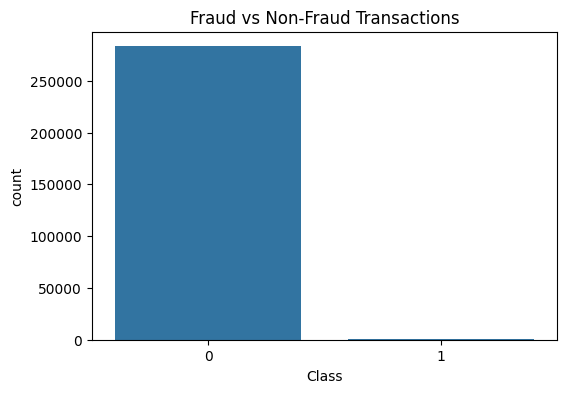

In [ ]:
# class distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [ ]:
# calculate fraud percentage
fraud = df["Class"].value_counts()[1]
normal = df["Class"].value_counts()[0]

print("Fraud Transactions :", fraud)
print("Normal Transactions:", normal)

print(
    "Fraud Percentage:",
    round((fraud/(fraud+normal))*100,4),
    "%"
)

Fraud Transactions : 473
Normal Transactions: 283253
Fraud Percentage: 0.1667 %


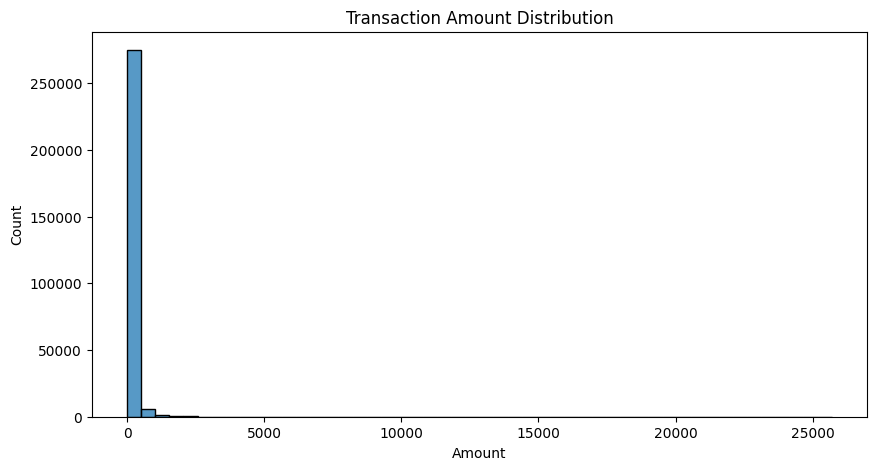

In [ ]:
# amount distribution
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.show()

Amount feature is rightly skewed so we will scale it later.

<Axes: xlabel='Amount', ylabel='Count'>

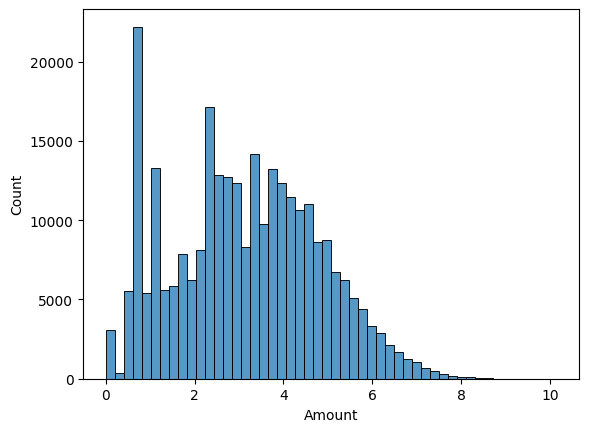

In [ ]:
sns.histplot(np.log1p(df["Amount"]), bins=50)

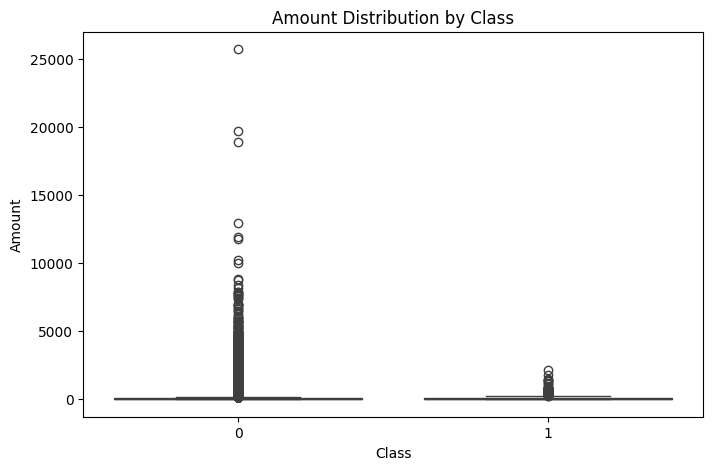

In [ ]:
# fraud vs Non-fraud Amount

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Amount Distribution by Class")
plt.show()

This shows that Amount alone cannot detect fraud.

## Time  Analysis:

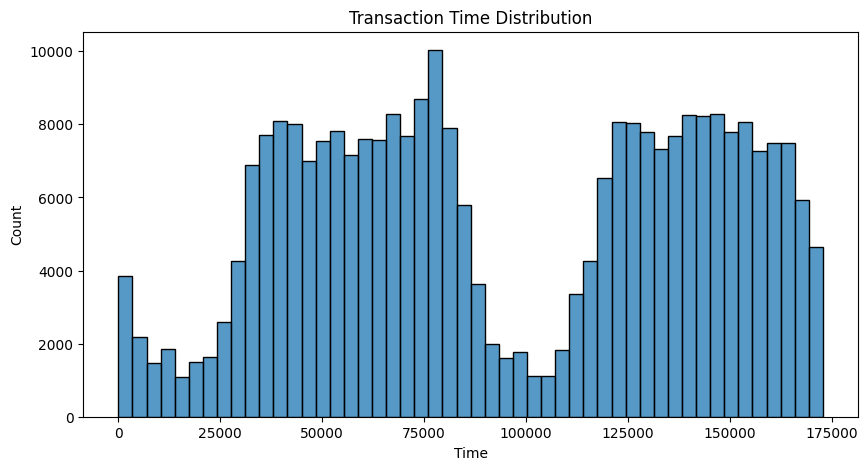

In [ ]:
# Time distribution
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.show()

The data spans: 0 → 172792 seconds

approximately: 172792 / 3600 ≈ **48 hours**

So the dataset contains:

**Two days** of transaction activity

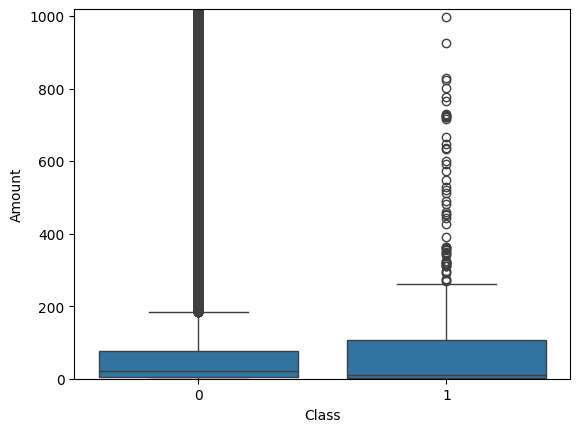

In [ ]:
sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.ylim(0, df["Amount"].quantile(0.99))
plt.show()

Fraud transactions appear to have a wider spread and many large-value outliers.
There are fraudulent transactions reaching very high amounts, but large amount alone does not mean fraud. Thus, we cannot conclude that Fraud happens mostly for high-value transactions

In [ ]:
corr = df.corr(numeric_only=True)["Class"].sort_values()

print(corr.sort_values(ascending=False).head(10), "\n")

print(corr.sort_values(ascending=True).head(10))

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64 

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V18   -0.105340
V1    -0.094486
V9    -0.094021
Name: Class, dtype: float64



V11, V4 have the strong positive relationship with fraud classes.



# Data Preprocessing

**Why not randomly shuffle everything?**

Because random splitting can allow the model to learn from future transaction patterns while evaluating on past-like data.

That can make your offline score look better than what you'd experience after deployment.

This is called **temporal leakage / unrealistic evaluation.**

In [ ]:
# Sort transactions chronologically
df = df.sort_values("Time").reset_index(drop=True)

# Define split points
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

# Create chronological splits
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["Time"].min(), "→", train_df["Time"].max())
print("Validation:", val_df["Time"].min(), "→", val_df["Time"].max())
print("Test:", test_df["Time"].min(), "→", test_df["Time"].max())

Train shape: (198608, 31)
Validation shape: (42559, 31)
Test shape: (42559, 31)

Time ranges:
Train: 0.0 → 132906.0
Validation: 132906.0 → 151320.0
Test: 151320.0 → 172792.0


In [ ]:
print("\nFraud distribution:")

print("\nTrain:")
print(train_df["Class"].value_counts())
print(train_df["Class"].value_counts(normalize=True) * 100)

print("\nValidation:")
print(val_df["Class"].value_counts())
print(val_df["Class"].value_counts(normalize=True) * 100)

print("\nTest:")
print(test_df["Class"].value_counts())
print(test_df["Class"].value_counts(normalize=True) * 100)


Fraud distribution:

Train:
Class
0    198242
1       366
Name: count, dtype: int64
Class
0    99.815717
1     0.184283
Name: proportion, dtype: float64

Validation:
Class
0    42504
1       55
Name: count, dtype: int64
Class
0    99.870768
1     0.129232
Name: proportion, dtype: float64

Test:
Class
0    42507
1       52
Name: count, dtype: int64
Class
0    99.877817
1     0.122183
Name: proportion, dtype: float64


In [ ]:
# Separate features and target

X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]

X_val = val_df.drop(columns=["Class"])
y_val = val_df["Class"]

X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]


# Check shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (198608, 30)
y_train: (198608,)
X_val: (42559, 30)
y_val: (42559,)
X_test: (42559, 30)
y_test: (42559,)


In [ ]:
print("Features:")
print(X_train.columns.tolist())

print("\nTarget:")
print(y_train.name)

Features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Target:
Class


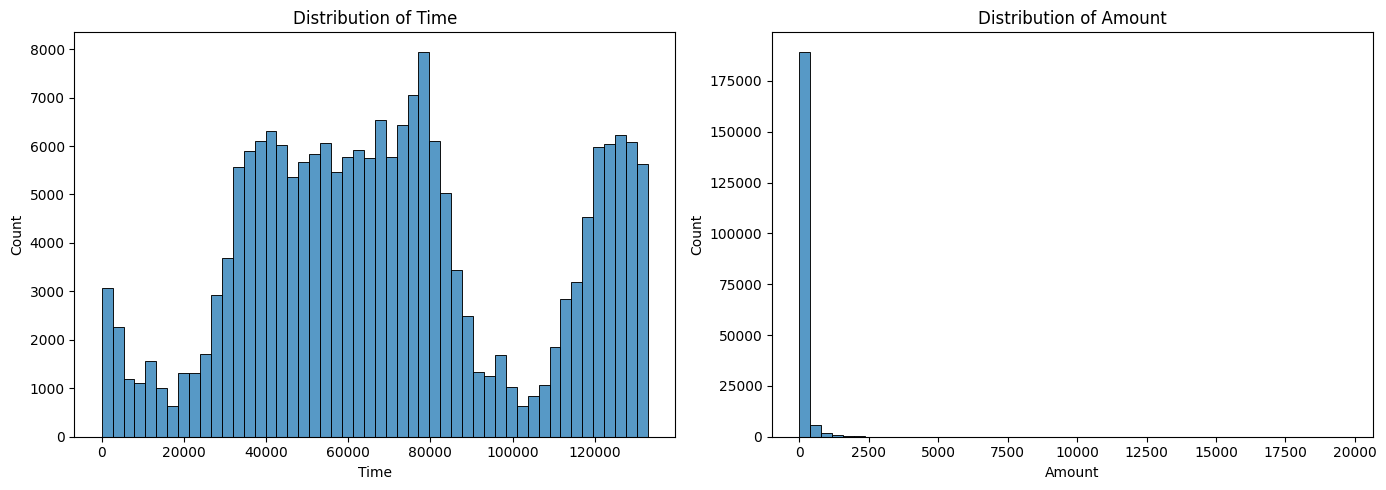

In [ ]:
# Inspect Time and Amount distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train["Time"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of Time")
axes[0].set_xlabel("Time")

sns.histplot(X_train["Amount"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of Amount")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

In [ ]:
print("Time skewness:", X_train["Time"].skew())
print("Amount skewness:", X_train["Amount"].skew())

Time skewness: 0.20474547387000688
Amount skewness: 14.647758825676297


In [ ]:
print(X_train[["Time", "Amount"]].describe())

                Time         Amount
count  198608.000000  198608.000000
mean    70446.279656      89.861441
std     34498.937759     249.157197
min         0.000000       0.000000
25%     44246.750000       5.990000
50%     67233.000000      23.000000
75%     91409.750000      79.540000
max    132906.000000   19656.530000


In [ ]:
# Create copies for preprocessing

X_train_prep = X_train.copy()
X_val_prep = X_val.copy()
X_test_prep = X_test.copy()


# Apply log transformation to Amount
X_train_prep["Amount"] = np.log1p(X_train_prep["Amount"])
X_val_prep["Amount"] = np.log1p(X_val_prep["Amount"])
X_test_prep["Amount"] = np.log1p(X_test_prep["Amount"])


# Check the new distribution
print("Original Amount skewness:",
      X_train["Amount"].skew())

print("Transformed Amount skewness:",
      X_train_prep["Amount"].skew())

Original Amount skewness: 14.647758825676297
Transformed Amount skewness: 0.1392661904112343


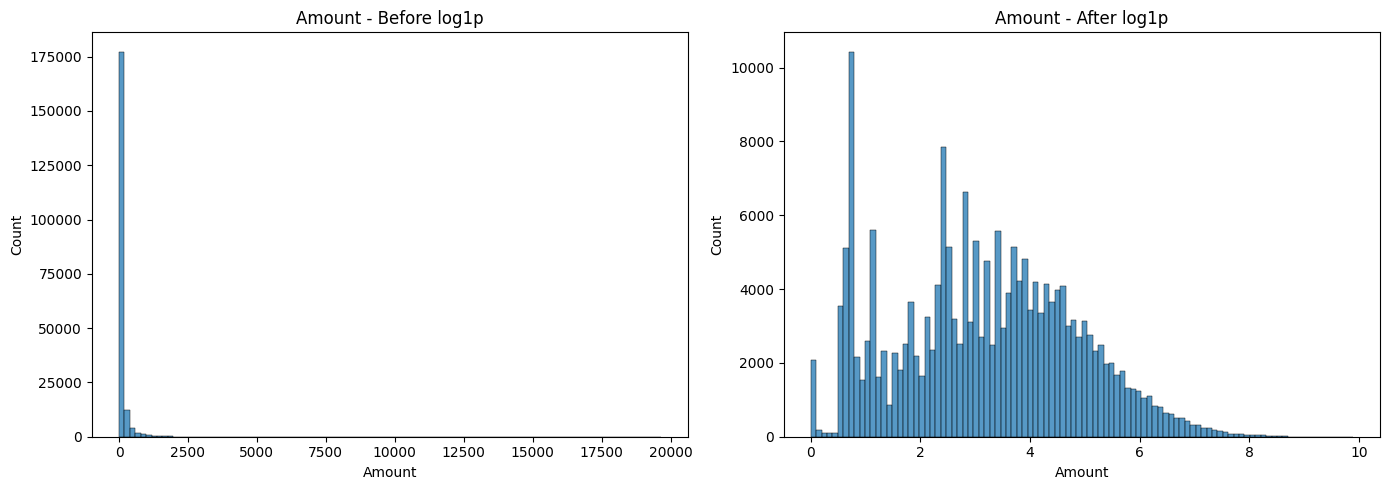

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train["Amount"], bins=100, ax=axes[0])
axes[0].set_title("Amount - Before log1p")

sns.histplot(X_train_prep["Amount"], bins=100, ax=axes[1])
axes[1].set_title("Amount - After log1p")

plt.tight_layout()
plt.show()

In [ ]:
print(X_train_prep["Amount"].describe())

count    198608.000000
mean          3.177722
std           1.658294
min           0.000000
25%           1.944481
50%           3.178054
75%           4.388754
max           9.886216
Name: Amount, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train_prep)

# Transform train, validation and test
X_train_scaled = scaler.transform(X_train_prep)
X_val_scaled = scaler.transform(X_val_prep)
X_test_scaled = scaler.transform(X_test_prep)

# Convert back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_prep.columns,
    index=X_train_prep.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val_prep.columns,
    index=X_val_prep.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_prep.columns,
    index=X_test_prep.index
)

In [ ]:
print("Training means:")
print(X_train_scaled.mean().round(3))

print("\nTraining standard deviations:")
print(X_train_scaled.std().round(3))

Training means:
Time      0.0
V1       -0.0
V2       -0.0
V3        0.0
V4       -0.0
V5       -0.0
V6        0.0
V7       -0.0
V8        0.0
V9       -0.0
V10      -0.0
V11      -0.0
V12       0.0
V13       0.0
V14      -0.0
V15      -0.0
V16      -0.0
V17      -0.0
V18      -0.0
V19       0.0
V20      -0.0
V21       0.0
V22      -0.0
V23       0.0
V24       0.0
V25      -0.0
V26       0.0
V27       0.0
V28       0.0
Amount   -0.0
dtype: float64

Training standard deviations:
Time      1.0
V1        1.0
V2        1.0
V3        1.0
V4        1.0
V5        1.0
V6        1.0
V7        1.0
V8        1.0
V9        1.0
V10       1.0
V11       1.0
V12       1.0
V13       1.0
V14       1.0
V15       1.0
V16       1.0
V17       1.0
V18       1.0
V19       1.0
V20       1.0
V21       1.0
V22       1.0
V23       1.0
V24       1.0
V25       1.0
V26       1.0
V27       1.0
V28       1.0
Amount    1.0
dtype: float64


In [ ]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (198608, 30)
X_val_scaled: (42559, 30)
X_test_scaled: (42559, 30)


## Establish an imbalanced-data baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Baseline Logistic Regression
baseline_lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train on ORIGINAL imbalanced training data
baseline_lr.fit(X_train_scaled, y_train)

# Predictions
y_val_pred = baseline_lr.predict(X_val_scaled)
y_val_proba = baseline_lr.predict_proba(X_val_scaled)[:, 1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

Confusion Matrix:
[[42496     8]
 [   28    27]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9996     42504
           1     0.7714    0.4909    0.6000        55

    accuracy                         0.9992     42559
   macro avg     0.8854    0.7454    0.7998     42559
weighted avg     0.9990    0.9992    0.9991     42559

ROC-AUC: 0.9814023920743289
PR-AUC: 0.749809347080156


In [ ]:
from sklearn.metrics import precision_recall_curve

# Calculate precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

# Calculate F1 for every threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Find threshold with maximum F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best precision:", precision[best_idx])
print("Best recall:", recall[best_idx])
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.09655954877007449
Best precision: 0.6911764705882353
Best recall: 0.8545454545454545
Best F1: 0.7642276422269813


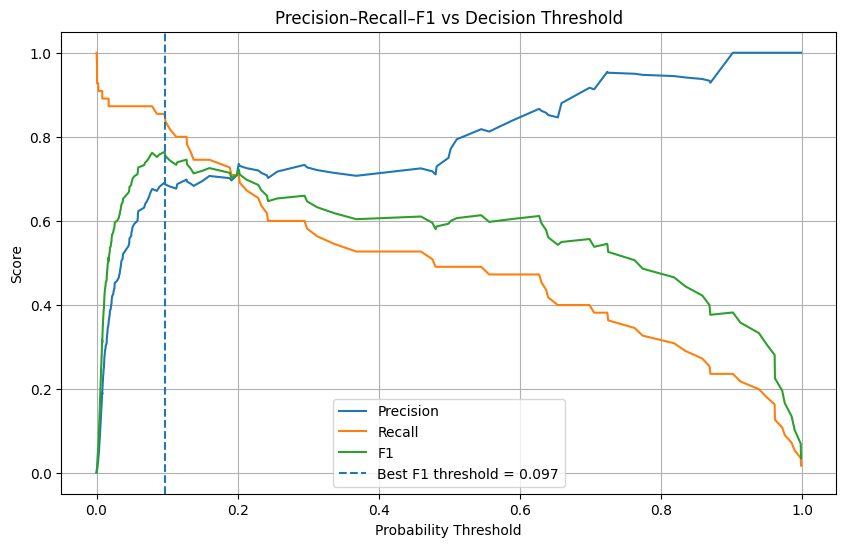

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_threshold:.3f}"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_val_pred_threshold = (
    y_val_proba >= best_threshold
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_threshold))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_threshold,
        digits=4
    )
)

Confusion Matrix:
[[42483    21]
 [    8    47]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9995    0.9997     42504
           1     0.6912    0.8545    0.7642        55

    accuracy                         0.9993     42559
   macro avg     0.8455    0.9270    0.8819     42559
weighted avg     0.9994    0.9993    0.9994     42559



In [ ]:
# Class-weighted Logistic Regression

weighted_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

weighted_lr.fit(X_train_scaled, y_train)

# Validation probabilities
y_val_proba_weighted = weighted_lr.predict_proba(X_val_scaled)[:, 1]

# Default threshold = 0.5
y_val_pred_weighted = (
    y_val_proba_weighted >= 0.5
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_weighted))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_weighted,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_weighted)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_proba_weighted)
)

Confusion Matrix:
[[41499  1005]
 [    4    51]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9764    0.9880     42504
           1     0.0483    0.9273    0.0918        55

    accuracy                         0.9763     42559
   macro avg     0.5241    0.9518    0.5399     42559
weighted avg     0.9987    0.9763    0.9868     42559

ROC-AUC: 0.9820354875690844
PR-AUC: 0.8143944992331854


In [ ]:
# optimize the threshold

precision_w, recall_w, thresholds_w = precision_recall_curve(
    y_val,
    y_val_proba_weighted
)

f1_w = (
    2 * precision_w[:-1] * recall_w[:-1]
    / (precision_w[:-1] + recall_w[:-1] + 1e-10)
)

best_idx_w = np.argmax(f1_w)

best_threshold_w = thresholds_w[best_idx_w]

print("Best threshold:", best_threshold_w)
print("Best precision:", precision_w[best_idx_w])
print("Best recall:", recall_w[best_idx_w])
print("Best F1:", f1_w[best_idx_w])

Best threshold: 0.9999960704676726
Best precision: 0.9047619047619048
Best recall: 0.6909090909090909
Best F1: 0.7835051545900734


In [ ]:
# Comapre Original Logistic Regression and Class-weighted Logistic Regression

from sklearn.metrics import precision_score, recall_score, f1_score

# --------------------------------------------------
# Baseline Logistic Regression
# --------------------------------------------------

y_baseline_threshold_pred = (
    y_val_proba >= best_threshold
).astype(int)

baseline_results = {
    "Model": "Logistic Regression",
    "ROC-AUC": roc_auc_score(y_val, y_val_proba),
    "PR-AUC": average_precision_score(y_val, y_val_proba),
    "Threshold": best_threshold,
    "Precision": precision_score(y_val, y_baseline_threshold_pred),
    "Recall": recall_score(y_val, y_baseline_threshold_pred),
    "F1": f1_score(y_val, y_baseline_threshold_pred)
}


# --------------------------------------------------
# Class-weighted Logistic Regression
# --------------------------------------------------

y_weighted_threshold_pred = (
    y_val_proba_weighted >= best_threshold_w
).astype(int)

weighted_results = {
    "Model": "Weighted Logistic Regression",
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_weighted),
    "PR-AUC": average_precision_score(y_val, y_val_proba_weighted),
    "Threshold": best_threshold_w,
    "Precision": precision_score(y_val, y_weighted_threshold_pred),
    "Recall": recall_score(y_val, y_weighted_threshold_pred),
    "F1": f1_score(y_val, y_weighted_threshold_pred)
}


# --------------------------------------------------
# Comparison
# --------------------------------------------------

comparison_df = pd.DataFrame([
    baseline_results,
    weighted_results
])

comparison_df

,Model,ROC-AUC,PR-AUC,Threshold,Precision,Recall,F1
0,Logistic Regression,0.981402,0.749809,0.096560,0.691176,0.854545,0.764228
1,Weighted Logistic Regression,0.982035,0.814394,0.999996,0.904762,0.690909,0.783505


In [ ]:
# Train a Random Forest baseline

from sklearn.ensemble import RandomForestClassifier

# Random Forest baseline
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train
rf_baseline.fit(X_train_scaled, y_train)

# Validation probabilities
y_val_proba_rf = rf_baseline.predict_proba(X_val_scaled)[:, 1]

# Default threshold
y_val_pred_rf = (y_val_proba_rf >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_proba_rf)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_proba_rf)
)

Confusion Matrix:
[[42504     0]
 [   17    38]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     42504
           1     1.0000    0.6909    0.8172        55

    accuracy                         0.9996     42559
   macro avg     0.9998    0.8455    0.9085     42559
weighted avg     0.9996    0.9996    0.9996     42559

ROC-AUC: 0.9691883544650343
PR-AUC: 0.8555301466390469


In [ ]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_val,
    y_val_proba_rf
)

f1_rf = (
    2 * precision_rf[:-1] * recall_rf[:-1]
    / (precision_rf[:-1] + recall_rf[:-1] + 1e-10)
)

best_idx_rf = np.argmax(f1_rf)

best_threshold_rf = thresholds_rf[best_idx_rf]

print("Best threshold:", best_threshold_rf)
print("Best precision:", precision_rf[best_idx_rf])
print("Best recall:", recall_rf[best_idx_rf])
print("Best F1:", f1_rf[best_idx_rf])

Best threshold: 0.405
Best precision: 1.0
Best recall: 0.7636363636363637
Best F1: 0.8659793813941971


In [ ]:
from xgboost import XGBClassifier

xgb_baseline = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_baseline.fit(X_train_scaled, y_train)

y_val_proba_xgb = xgb_baseline.predict_proba(X_val_scaled)[:, 1]
y_val_pred_xgb = (y_val_proba_xgb >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_xgb, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_xgb))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_xgb))

Confusion Matrix:
[[42503     1]
 [   14    41]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998     42504
           1     0.9762    0.7455    0.8454        55

    accuracy                         0.9996     42559
   macro avg     0.9879    0.8727    0.9226     42559
weighted avg     0.9996    0.9996    0.9996     42559

ROC-AUC: 0.9854238317677053
PR-AUC: 0.8587175791181545


In [ ]:
# Optimize XGBoost threshold

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_val, y_val_proba_xgb
)

f1_xgb = (
    2 * precision_xgb[:-1] * recall_xgb[:-1]
    / (precision_xgb[:-1] + recall_xgb[:-1] + 1e-10)
)

best_idx_xgb = np.argmax(f1_xgb)
best_threshold_xgb = thresholds_xgb[best_idx_xgb]

print("Best threshold:", best_threshold_xgb)
print("Best precision:", precision_xgb[best_idx_xgb])
print("Best recall:", recall_xgb[best_idx_xgb])
print("Best F1:", f1_xgb[best_idx_xgb])

Best threshold: 0.21932721
Best precision: 0.9782608695652174
Best recall: 0.8181818181818182
Best F1: 0.8910891088612881


We still cannot call it the final model, because the threshold and model were evaluated using the validation set. The test set must remain untouched until the final decision.

In [ ]:
from lightgbm import LGBMClassifier

lgbm_baseline = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgbm_baseline.fit(X_train_scaled, y_train)

y_val_proba_lgbm = lgbm_baseline.predict_proba(X_val_scaled)[:, 1]
y_val_pred_lgbm = (y_val_proba_lgbm >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lgbm, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_lgbm))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_lgbm))

Confusion Matrix:
[[42410    94]
 [   23    32]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9978    0.9986     42504
           1     0.2540    0.5818    0.3536        55

    accuracy                         0.9973     42559
   macro avg     0.6267    0.7898    0.6761     42559
weighted avg     0.9985    0.9973    0.9978     42559

ROC-AUC: 0.8234134113580753
PR-AUC: 0.39242178323762206


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

catboost_baseline = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1
)

catboost_baseline.fit(X_train_scaled, y_train)

y_val_proba_cat = catboost_baseline.predict_proba(X_val_scaled)[:, 1]
y_val_pred_cat = (y_val_proba_cat >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_cat))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_cat, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_cat))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_cat))

Confusion Matrix:
[[42504     0]
 [   11    44]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9999     42504
           1     1.0000    0.8000    0.8889        55

    accuracy                         0.9997     42559
   macro avg     0.9999    0.9000    0.9444     42559
weighted avg     0.9997    0.9997    0.9997     42559

ROC-AUC: 0.9814272025734477
PR-AUC: 0.8553065738500716


In [ ]:
# Optimize catboost threshold

precision_cat, recall_cat, thresholds_cat = precision_recall_curve(
    y_val, y_val_proba_cat
)

f1_cat = (
    2 * precision_cat[:-1] * recall_cat[:-1]
    / (precision_cat[:-1] + recall_cat[:-1] + 1e-10)
)

best_idx_cat = np.argmax(f1_cat)
best_threshold_cat = thresholds_cat[best_idx_cat]

print("Best threshold:", best_threshold_cat)
print("Best precision:", precision_cat[best_idx_cat])
print("Best recall:", recall_cat[best_idx_cat])
print("Best F1:", f1_cat[best_idx_cat])

Best threshold: 0.5180010349258749
Best precision: 1.0
Best recall: 0.8
Best F1: 0.8888888888395062


# Model comparison

In [ ]:

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "ROC_AUC": [
        0.9814023921,
        0.9820354876,
        0.9691883545,
        0.9854238318,
        0.8234134114,
        0.9814272026
    ],
    "PR_AUC": [
        0.7498093471,
        0.8143944992,
        0.8555301466,
        0.8587175791,
        0.3924217832,
        0.8553065739
    ],
    "Best_Threshold": [
        best_threshold,
        best_threshold_w,
        best_threshold_rf,
        best_threshold_xgb,
        np.nan,
        best_threshold_cat
    ],
    "Best_Precision": [
        precision[best_idx],
        precision_w[best_idx_w],
        precision_rf[best_idx_rf],
        precision_xgb[best_idx_xgb],
        np.nan,
        precision_cat[best_idx_cat]
    ],
    "Best_Recall": [
        recall[best_idx],
        recall_w[best_idx_w],
        recall_rf[best_idx_rf],
        recall_xgb[best_idx_xgb],
        np.nan,
        recall_cat[best_idx_cat]
    ],
    "Best_F1": [
        f1_scores[best_idx],
        f1_w[best_idx_w],
        f1_rf[best_idx_rf],
        f1_xgb[best_idx_xgb],
        np.nan,
        f1_cat[best_idx_cat]
    ]
})

model_comparison.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

,Model,ROC_AUC,PR_AUC,Best_Threshold,Best_Precision,Best_Recall,Best_F1
0,XGBoost,0.985424,0.858718,0.219327,0.978261,0.818182,0.891089
1,Random Forest,0.969188,0.855530,0.405000,1.000000,0.763636,0.865979
2,CatBoost,0.981427,0.855307,0.518001,1.000000,0.800000,0.888889
3,Weighted Logistic Regression,0.982035,0.814394,0.999996,0.904762,0.690909,0.783505
4,Logistic Regression,0.981402,0.749809,0.096560,0.691176,0.854545,0.764228
5,LightGBM,0.823413,0.392422,NaN,NaN,NaN,NaN


In [ ]:
# Tune XGBoost

from sklearn.model_selection import RandomizedSearchCV

xgb_tuning = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_dist_xgb = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_dist_xgb,
    n_iter=15,
    scoring="average_precision",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search_xgb.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(random_search_xgb.best_params_)

print("\nBest CV PR-AUC:")
print(random_search_xgb.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}

Best CV PR-AUC:
0.7794913875288922


In [ ]:
# Evaluate the tuned XGBoost on validation

best_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    gamma=0.1,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb.fit(X_train_scaled, y_train)

y_val_proba_xgb_tuned = best_xgb.predict_proba(X_val_scaled)[:, 1]

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_xgb_tuned))

print("PR-AUC:",
      average_precision_score(y_val, y_val_proba_xgb_tuned))

ROC-AUC: 0.9861993737487809
PR-AUC: 0.8676252260347529


In [ ]:
# Optimize the tuned XGBoost threshold

precision_tuned_xgb, recall_tuned_xgb, thresholds_tuned_xgb = (
    precision_recall_curve(
        y_val,
        y_val_proba_xgb_tuned
    )
)

f1_tuned_xgb = (
    2 * precision_tuned_xgb[:-1] * recall_tuned_xgb[:-1]
    / (
        precision_tuned_xgb[:-1]
        + recall_tuned_xgb[:-1]
        + 1e-10
    )
)

best_idx_tuned_xgb = np.argmax(f1_tuned_xgb)
best_threshold_tuned_xgb = thresholds_tuned_xgb[best_idx_tuned_xgb]

print("Best threshold:", best_threshold_tuned_xgb)
print("Best precision:", precision_tuned_xgb[best_idx_tuned_xgb])
print("Best recall:", recall_tuned_xgb[best_idx_tuned_xgb])
print("Best F1:", f1_tuned_xgb[best_idx_tuned_xgb])

Best threshold: 0.06395385
Best precision: 0.8703703703703703
Best recall: 0.8545454545454545
Best F1: 0.8623853210509217


In [ ]:
# Inspect the tuned XGBoost confusion matrix

y_val_pred_tuned_xgb = (
    y_val_proba_xgb_tuned >= best_threshold_tuned_xgb
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_tuned_xgb))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_tuned_xgb,
        digits=4
    )
)

Confusion Matrix:
[[42497     7]
 [    8    47]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     42504
           1     0.8704    0.8545    0.8624        55

    accuracy                         0.9996     42559
   macro avg     0.9351    0.9272    0.9311     42559
weighted avg     0.9996    0.9996    0.9996     42559



In [ ]:
# Create final model comparison

final_candidates = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost",
        "Random Forest",
        "CatBoost"
    ],
    "ROC_AUC": [
        0.9854238318,
        0.9861993737,
        0.9691883545,
        0.9814272026
    ],
    "PR_AUC": [
        0.8587175791,
        0.8676252260,
        0.8555301466,
        0.8553065739
    ],
    "Threshold": [
        best_threshold_xgb,
        best_threshold_tuned_xgb,
        best_threshold_rf,
        best_threshold_cat
    ],
    "Precision": [
        precision_xgb[best_idx_xgb],
        precision_tuned_xgb[best_idx_tuned_xgb],
        precision_rf[best_idx_rf],
        precision_cat[best_idx_cat]
    ],
    "Recall": [
        recall_xgb[best_idx_xgb],
        recall_tuned_xgb[best_idx_tuned_xgb],
        recall_rf[best_idx_rf],
        recall_cat[best_idx_cat]
    ],
    "F1": [
        f1_xgb[best_idx_xgb],
        f1_tuned_xgb[best_idx_tuned_xgb],
        f1_rf[best_idx_rf],
        f1_cat[best_idx_cat]
    ]
})

final_candidates.sort_values(
    by=["PR_AUC", "F1"],
    ascending=False
).reset_index(drop=True)

,Model,ROC_AUC,PR_AUC,Threshold,Precision,Recall,F1
0,Tuned XGBoost,0.986199,0.867625,0.063954,0.870370,0.854545,0.862385
1,Baseline XGBoost,0.985424,0.858718,0.219327,0.978261,0.818182,0.891089
2,Random Forest,0.969188,0.855530,0.405000,1.000000,0.763636,0.865979
3,CatBoost,0.981427,0.855307,0.518001,1.000000,0.800000,0.888889


In [ ]:
# Calculate validation performance at several practical thresholds

thresholds_to_check = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.25, 0.30]

threshold_results = []

for threshold in thresholds_to_check:
    y_pred = (y_val_proba_xgb_tuned >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val, y_pred
    ).ravel()

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = (
        2 * precision_val * recall_val /
        (precision_val + recall_val)
        if (precision_val + recall_val) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "F1": f1_val,
        "False_Positives": fp,
        "False_Negatives": fn
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1,False_Positives,False_Negatives
0,0.03,0.691176,0.854545,0.764228,21,8
1,0.05,0.839286,0.854545,0.846847,9,8
2,0.07,0.865385,0.818182,0.841121,7,10
3,0.10,0.897959,0.800000,0.846154,5,11
4,0.15,0.954545,0.763636,0.848485,2,13
5,0.20,0.976190,0.745455,0.845361,1,14
6,0.25,0.976190,0.745455,0.845361,1,14
7,0.30,0.976190,0.745455,0.845361,1,14


In [ ]:
# Maximum false positives we are willing to accept
MAX_FALSE_POSITIVES = 10

threshold_results = []

# Use every threshold generated by the precision-recall curve
for threshold in thresholds_to_check:

    y_pred = (
        y_val_proba_xgb_tuned >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision_val = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall_val = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })


threshold_df = pd.DataFrame(threshold_results)

# ---------------------------------------------------------
# FILTER: ONLY THRESHOLDS WITH ACCEPTABLE FALSE POSITIVES
# ---------------------------------------------------------

acceptable = threshold_df[
    threshold_df["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

if len(acceptable) == 0:

    print(
        f"No threshold satisfies the maximum "
        f"false-positive limit of {MAX_FALSE_POSITIVES}."
    )

else:

    # PRIMARY OBJECTIVE:
    #     maximize recall
    #
    # SECONDARY OBJECTIVE:
    #     if recall is tied, minimize false positives
    #
    # THIRD OBJECTIVE:
    #     if still tied, choose the higher threshold

    selected_row = acceptable.sort_values(
        by=[
            "Recall",
            "False_Positives",
            "Threshold"
        ],
        ascending=[
            False,
            True,
            False
        ]
    ).iloc[0]

    print("Selected Threshold:",
          selected_row["Threshold"])

    print("Precision:",
          selected_row["Precision"])

    print("Recall:",
          selected_row["Recall"])

    print("False Positives:",
          int(selected_row["False_Positives"]))

    print("False Negatives:",
          int(selected_row["False_Negatives"]))

    print("True Positives:",
          int(selected_row["True_Positives"]))

    print("True Negatives:",
          int(selected_row["True_Negatives"]))

Selected Threshold: 0.05
Precision: 0.8392857142857143
Recall: 0.8545454545454545
False Positives: 9
False Negatives: 8
True Positives: 47
True Negatives: 42495


In [ ]:
#  Final test evaluation

# Freeze the threshold selected using validation data
FINAL_THRESHOLD = 0.06395384669303894

# Generate probabilities on the completely untouched test set
y_test_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Convert probabilities into fraud predictions
y_test_pred = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

print("FINAL TEST CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_test_pred))

print("\nFINAL TEST CLASSIFICATION REPORT:")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

print("FINAL TEST ROC-AUC:",
      roc_auc_score(y_test, y_test_proba))

print("FINAL TEST PR-AUC:",
      average_precision_score(y_test, y_test_proba))

FINAL TEST CONFUSION MATRIX:
[[42494    13]
 [   13    39]]

FINAL TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     42507
           1     0.7500    0.7500    0.7500        52

    accuracy                         0.9994     42559
   macro avg     0.8748    0.8748    0.8748     42559
weighted avg     0.9994    0.9994    0.9994     42559

FINAL TEST ROC-AUC: 0.9726601591412093
FINAL TEST PR-AUC: 0.7615978258133079


In [ ]:
# Test Random undersampling

from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

rus = RandomUnderSampler(
    sampling_strategy=0.1,
    random_state=RANDOM_STATE
)

X_train_rus, y_train_rus = rus.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(Counter(y_train))

print("\nAfter Random UnderSampling:")
print(Counter(y_train_rus))

print("\nShapes:")
print("X_train_rus:", X_train_rus.shape)
print("y_train_rus:", y_train_rus.shape)

Original training distribution:
Counter({0: 198242, 1: 366})

After Random UnderSampling:
Counter({0: 3660, 1: 366})

Shapes:
X_train_rus: (4026, 30)
y_train_rus: (4026,)


In [ ]:
xgb_rus = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    gamma=0.1,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_rus.fit(X_train_rus, y_train_rus)

y_val_proba_rus = xgb_rus.predict_proba(X_val_scaled)[:, 1]

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_val_pred_rus = (y_val_proba_rus >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rus))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rus, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_rus))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_rus))

Confusion Matrix:
[[42408    96]
 [    6    49]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9977    0.9988     42504
           1     0.3379    0.8909    0.4900        55

    accuracy                         0.9976     42559
   macro avg     0.6689    0.9443    0.7444     42559
weighted avg     0.9990    0.9976    0.9981     42559

ROC-AUC: 0.9829547593381586
PR-AUC: 0.8413588067275066


In [ ]:
MAX_FALSE_POSITIVES = 10

thresholds_rus = np.sort(np.unique(y_val_proba_rus))

threshold_results_rus = []

for threshold in thresholds_rus:
    y_pred = (y_val_proba_rus >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0

    threshold_results_rus.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

threshold_df_rus = pd.DataFrame(threshold_results_rus)

acceptable_rus = threshold_df_rus[
    threshold_df_rus["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_rus = acceptable_rus.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("Selected threshold:", selected_rus["Threshold"])
print("Precision:", selected_rus["Precision"])
print("Recall:", selected_rus["Recall"])
print("False Positives:", selected_rus["False_Positives"])
print("False Negatives:", selected_rus["False_Negatives"])
print("True Positives:", selected_rus["True_Positives"])
print("True Negatives:", selected_rus["True_Negatives"])

Selected threshold: 0.931878924369812
Precision: 0.8113207547169812
Recall: 0.7818181818181819
False Positives: 10.0
False Negatives: 12.0
True Positives: 43.0
True Negatives: 42494.0


Under-sampling does not improve our selected operating point.

In fact, with the same maximum of 10 false positives, the original tuned XGBoost catches 4 more frauds.

Therefore, for our current objective, we don't need to use Random UnderSampling as the final training strategy.

# Test SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    sampling_strategy=0.1,
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(Counter(y_train))

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

print("\nShapes:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

Original training distribution:
Counter({0: 198242, 1: 366})

After SMOTE:
Counter({0: 198242, 1: 19824})

Shapes:
X_train_smote: (218066, 30)
y_train_smote: (218066,)


In [ ]:
xgb_smote = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    gamma=0.1,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_val_proba_smote = xgb_smote.predict_proba(X_val_scaled)[:, 1]

print("XGBoost + SMOTE trained successfully.")

XGBoost + SMOTE trained successfully.


In [ ]:
y_val_pred_smote = (y_val_proba_smote >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_smote))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_smote, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_smote))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_smote))

Confusion Matrix:
[[42503     1]
 [   14    41]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998     42504
           1     0.9762    0.7455    0.8454        55

    accuracy                         0.9996     42559
   macro avg     0.9879    0.8727    0.9226     42559
weighted avg     0.9996    0.9996    0.9996     42559

ROC-AUC: 0.9905865544205466
PR-AUC: 0.8539537917022646


At threshold 0.5, SMOTE produced exactly the same confusion matrix and precision/recall as our original XGBoost. That suggests SMOTE may have improved the model's ranking ability, even though the default 0.5 operating point hasn't changed but PR-AUC is slightly lower than the original model.

In [ ]:
MAX_FALSE_POSITIVES = 10

thresholds_smote = np.sort(np.unique(y_val_proba_smote))

threshold_results_smote = []

for threshold in thresholds_smote:
    y_pred = (y_val_proba_smote >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0

    threshold_results_smote.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

threshold_df_smote = pd.DataFrame(threshold_results_smote)

acceptable_smote = threshold_df_smote[
    threshold_df_smote["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_smote = acceptable_smote.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("Selected threshold:", selected_smote["Threshold"])
print("Precision:", selected_smote["Precision"])
print("Recall:", selected_smote["Recall"])
print("False Positives:", selected_smote["False_Positives"])
print("False Negatives:", selected_smote["False_Negatives"])
print("True Positives:", selected_smote["True_Positives"])
print("True Negatives:", selected_smote["True_Negatives"])

Selected threshold: 0.18594521284103394
Precision: 0.86
Recall: 0.7818181818181819
False Positives: 7.0
False Negatives: 12.0
True Positives: 43.0
True Negatives: 42497.0


For our chosen operating constraint, SMOTE does not beat the original XGBoost.
# Apply SMOTETomek

In [ ]:
from imblearn.combine import SMOTETomek
from collections import Counter

smotetomek = SMOTETomek(
    sampling_strategy=0.1,
    random_state=RANDOM_STATE
)

X_train_smt, y_train_smt = smotetomek.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training distribution:")
print(Counter(y_train))

print("\nAfter SMOTETomek:")
print(Counter(y_train_smt))

print("\nShapes:")
print("X_train_smt:", X_train_smt.shape)
print("y_train_smt:", y_train_smt.shape)

Original training distribution:
Counter({0: 198242, 1: 366})

After SMOTETomek:
Counter({0: 198242, 1: 19824})

Shapes:
X_train_smt: (218066, 30)
y_train_smt: (218066,)


In [ ]:
xgb_smt = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    gamma=0.1,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_smt.fit(X_train_smt, y_train_smt)

y_val_proba_smt = xgb_smt.predict_proba(X_val_scaled)[:, 1]

print("XGBoost + SMOTETomek trained successfully.")

XGBoost + SMOTETomek trained successfully.


In [ ]:
y_val_pred_smt = (y_val_proba_smt >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_smt))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_smt, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_val_proba_smt))
print("PR-AUC:", average_precision_score(y_val, y_val_proba_smt))

Confusion Matrix:
[[42503     1]
 [   14    41]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9998     42504
           1     0.9762    0.7455    0.8454        55

    accuracy                         0.9996     42559
   macro avg     0.9879    0.8727    0.9226     42559
weighted avg     0.9996    0.9996    0.9996     42559

ROC-AUC: 0.9905865544205466
PR-AUC: 0.8539537917022646


SMOTETomek gives exactly the same validation result as SMOTE.

In [ ]:
MAX_FALSE_POSITIVES = 10

thresholds_smt = np.sort(np.unique(y_val_proba_smt))

threshold_results_smt = []

for threshold in thresholds_smt:
    y_pred = (y_val_proba_smt >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0

    threshold_results_smt.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

threshold_df_smt = pd.DataFrame(threshold_results_smt)

acceptable_smt = threshold_df_smt[
    threshold_df_smt["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_smt = acceptable_smt.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("Selected threshold:", selected_smt["Threshold"])
print("Precision:", selected_smt["Precision"])
print("Recall:", selected_smt["Recall"])
print("False Positives:", selected_smt["False_Positives"])
print("False Negatives:", selected_smt["False_Negatives"])
print("True Positives:", selected_smt["True_Positives"])
print("True Negatives:", selected_smt["True_Negatives"])

Selected threshold: 0.18594521284103394
Precision: 0.86
Recall: 0.7818181818181819
False Positives: 7.0
False Negatives: 12.0
True Positives: 43.0
True Negatives: 42497.0


SMOTETomek technique does not improvized much.

 It was worth testing balanced-data approaches — and we've now tested them. But none of them improved our chosen operating point.

 # Model improvization


In [ ]:
print(best_xgb.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'aucpr', 'feature_types': None, 'feature_weights': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 8, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 500, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [ ]:
# Can regularization improve the model's ability to rank fraud cases on unseen validation data?

from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

regularization_results = []

reg_alpha_values = [0, 0.01, 0.1, 1]
reg_lambda_values = [1, 2, 5, 10]

for alpha in reg_alpha_values:
    for reg_lambda in reg_lambda_values:

        model = XGBClassifier(
            n_estimators=500,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=5,
            gamma=0.1,
            reg_alpha=alpha,
            reg_lambda=reg_lambda,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train)

        val_proba = model.predict_proba(X_val_scaled)[:, 1]

        pr_auc = average_precision_score(y_val, val_proba)

        regularization_results.append({
            "reg_alpha": alpha,
            "reg_lambda": reg_lambda,
            "PR_AUC": pr_auc
        })

regularization_df = pd.DataFrame(regularization_results)

regularization_df = regularization_df.sort_values(
    "PR_AUC",
    ascending=False
).reset_index(drop=True)

print(regularization_df)

    reg_alpha  reg_lambda    PR_AUC
0        0.00           1  0.867625
1        0.10           5  0.867434
2        0.01           5  0.866515
3        0.01           1  0.865850
4        0.00           5  0.864927
5        1.00           5  0.863833
6        0.01           2  0.863651
7        1.00           1  0.861992
8        1.00           2  0.861478
9        0.10           1  0.860844
10       0.00           2  0.860625
11       0.10           2  0.860493
12       0.01          10  0.857846
13       0.00          10  0.856955
14       0.10          10  0.854870
15       1.00          10  0.852116


In [ ]:
depth_results = []

max_depth_values = [4, 6, 8, 10]
min_child_weight_values = [1, 3, 5, 10]

for depth in max_depth_values:
    for child_weight in min_child_weight_values:

        model = XGBClassifier(
            n_estimators=500,
            max_depth=depth,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_weight=child_weight,
            gamma=0.1,
            reg_alpha=0,
            reg_lambda=1,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(X_train_scaled, y_train)

        val_proba = model.predict_proba(X_val_scaled)[:, 1]

        pr_auc = average_precision_score(y_val, val_proba)

        depth_results.append({
            "max_depth": depth,
            "min_child_weight": child_weight,
            "PR_AUC": pr_auc
        })

depth_df = pd.DataFrame(depth_results)

depth_df = depth_df.sort_values(
    "PR_AUC",
    ascending=False
).reset_index(drop=True)

print(depth_df)

    max_depth  min_child_weight    PR_AUC
0           6                 3  0.877332
1           8                 3  0.876836
2          10                 3  0.871306
3           6                 1  0.870813
4          10                 1  0.870468
5           8                 1  0.870250
6           8                 5  0.867625
7           4                 3  0.866204
8          10                 5  0.864207
9           4                 5  0.862111
10          6                 5  0.861672
11          4                 1  0.860361
12          8                10  0.855174
13         10                10  0.855174
14          6                10  0.851658
15          4                10  0.849307


In [ ]:
improved_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0,
    reg_lambda=1,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

improved_xgb.fit(X_train_scaled, y_train)

y_val_proba_improved = improved_xgb.predict_proba(X_val_scaled)[:, 1]

print("Improved XGBoost trained successfully.")
print(
    "Validation PR-AUC:",
    average_precision_score(y_val, y_val_proba_improved)
)

Improved XGBoost trained successfully.
Validation PR-AUC: 0.8773321410071596


PR-AUC gain 1.12% relative improvement.

In [ ]:
MAX_FALSE_POSITIVES = 10

thresholds_improved = np.sort(np.unique(y_val_proba_improved))

threshold_results_improved = []

for threshold in thresholds_improved:
    y_pred = (y_val_proba_improved >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0

    threshold_results_improved.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

threshold_df_improved = pd.DataFrame(threshold_results_improved)

acceptable_improved = threshold_df_improved[
    threshold_df_improved["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_improved = acceptable_improved.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("Selected threshold:", selected_improved["Threshold"])
print("Precision:", selected_improved["Precision"])
print("Recall:", selected_improved["Recall"])
print("False Positives:", selected_improved["False_Positives"])
print("False Negatives:", selected_improved["False_Negatives"])
print("True Positives:", selected_improved["True_Positives"])
print("True Negatives:", selected_improved["True_Negatives"])

Selected threshold: 0.04832106828689575
Precision: 0.8392857142857143
Recall: 0.8545454545454545
False Positives: 9.0
False Negatives: 8.0
True Positives: 47.0
True Negatives: 42495.0


This Tuned XGBoost catches the same 47/55 frauds, misses the same 8 frauds and uses 2 additional false positives compared to previous optimized XGBoost.

We will try:

## Ensemble techniques:

In [ ]:
print("Improved XGBoost:", len(y_val_proba_improved))
print("Random Forest:", len(y_val_proba_rf))
print("CatBoost:", len(y_val_proba_cat))
print("Validation labels:", len(y_val))

Improved XGBoost: 42559
Random Forest: 42559
CatBoost: 42559
Validation labels: 42559


In [ ]:
# Create and evaluate the equal-weight ensemble

from sklearn.metrics import average_precision_score, roc_auc_score

y_val_proba_ensemble = (
    y_val_proba_improved
    + y_val_proba_rf
    + y_val_proba_cat
) / 3

print("Ensemble ROC-AUC:",
      roc_auc_score(y_val, y_val_proba_ensemble))

print("Ensemble PR-AUC:",
      average_precision_score(y_val, y_val_proba_ensemble))

Ensemble ROC-AUC: 0.9832353746385367
Ensemble PR-AUC: 0.8675980986503514


The ensemble's PR-AUC of 0.867598 is essentially back to the old XGBoost level and below the improved XGBoost's 0.877332.

In [ ]:
# Test a few simple weighted ensembles

ensemble_results = []

weight_configs = [
    (0.6, 0.2, 0.2),
    (0.7, 0.15, 0.15),
    (0.8, 0.1, 0.1),
    (0.5, 0.25, 0.25),
    (0.7, 0.2, 0.1),
    (0.7, 0.1, 0.2)
]

for wxgb, wrf, wcat in weight_configs:

    ensemble_proba = (
        wxgb * y_val_proba_improved
        + wrf * y_val_proba_rf
        + wcat * y_val_proba_cat
    )

    pr_auc = average_precision_score(
        y_val,
        ensemble_proba
    )

    roc_auc = roc_auc_score(
        y_val,
        ensemble_proba
    )

    ensemble_results.append({
        "XGB_weight": wxgb,
        "RF_weight": wrf,
        "CatBoost_weight": wcat,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc
    })

ensemble_df = pd.DataFrame(ensemble_results)

ensemble_df = ensemble_df.sort_values(
    "PR_AUC",
    ascending=False
).reset_index(drop=True)

print(ensemble_df)

   XGB_weight  RF_weight  CatBoost_weight    PR_AUC   ROC_AUC
0         0.8       0.10             0.10  0.876263  0.984712
1         0.7       0.10             0.20  0.873908  0.984076
2         0.7       0.15             0.15  0.873400  0.984274
3         0.7       0.20             0.10  0.873309  0.984559
4         0.6       0.20             0.20  0.872410  0.983932
5         0.5       0.25             0.25  0.872094  0.983625


Best weighted ensemble: 80% XGBoost + 10% RF + 10% CatBoost

(PR-AUC = 0.876263)

So, the ensemble is slightly worse than XGBoost alone.

In [ ]:
# Create the best weighted ensemble and optimize its threshold

best_ensemble_proba = (
    0.80 * y_val_proba_improved
    + 0.10 * y_val_proba_rf
    + 0.10 * y_val_proba_cat
)

MAX_FALSE_POSITIVES = 10

thresholds_ensemble = np.sort(
    np.unique(best_ensemble_proba)
)

ensemble_threshold_results = []

for threshold in thresholds_ensemble:

    y_pred = (
        best_ensemble_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision_val = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall_val = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    ensemble_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

ensemble_threshold_df = pd.DataFrame(
    ensemble_threshold_results
)

acceptable_ensemble = ensemble_threshold_df[
    ensemble_threshold_df["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_ensemble = acceptable_ensemble.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("Selected threshold:", selected_ensemble["Threshold"])
print("Precision:", selected_ensemble["Precision"])
print("Recall:", selected_ensemble["Recall"])
print("False Positives:", selected_ensemble["False_Positives"])
print("False Negatives:", selected_ensemble["False_Negatives"])
print("True Positives:", selected_ensemble["True_Positives"])
print("True Negatives:", selected_ensemble["True_Negatives"])

Selected threshold: 0.10605342673394617
Precision: 0.9375
Recall: 0.8181818181818182
False Positives: 3.0
False Negatives: 10.0
True Positives: 45.0
True Negatives: 42501.0


Our stated priority is catching as many frauds as possible, so the improved XGBoost remains preferable for that objective.

Improved XGBoost is currently the strongest individual candidate for the recall-first objective. The ensemble is useful if reducing false positives becomes more important.

In [ ]:
xgb_early = XGBClassifier(
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0,
    reg_lambda=1,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_early.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

y_val_proba_early = xgb_early.predict_proba(
    X_val_scaled
)[:, 1]

print("Best iteration:", xgb_early.best_iteration)
print("Best validation PR-AUC:", xgb_early.best_score)
print(
    "Calculated PR-AUC:",
    average_precision_score(y_val, y_val_proba_early)
)

Best iteration: 100
Best validation PR-AUC: 0.8852409324745245
Calculated PR-AUC: 0.8854745890348648


In [ ]:
# Optimize the early-stopping model's threshold

MAX_FALSE_POSITIVES = 10

thresholds_early = np.sort(
    np.unique(y_val_proba_early)
)

early_threshold_results = []

for threshold in thresholds_early:

    y_pred = (
        y_val_proba_early >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision_val = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall_val = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    early_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

early_threshold_df = pd.DataFrame(
    early_threshold_results
)

acceptable_early = early_threshold_df[
    early_threshold_df["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_early = acceptable_early.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("Selected threshold:", selected_early["Threshold"])
print("Precision:", selected_early["Precision"])
print("Recall:", selected_early["Recall"])
print("False Positives:", selected_early["False_Positives"])
print("False Negatives:", selected_early["False_Negatives"])
print("True Positives:", selected_early["True_Positives"])
print("True Negatives:", selected_early["True_Negatives"])

Selected threshold: 0.09133733808994293
Precision: 0.8571428571428571
Recall: 0.8727272727272727
False Positives: 8.0
False Negatives: 7.0
True Positives: 48.0
True Negatives: 42496.0


The early-stopping model is currently our best candidate at the actual operating point.

In [ ]:
# Freeze the current best candidate
final_model_candidate = xgb_early
final_threshold_candidate = float(selected_early["Threshold"])

print("Final model candidate: Early-Stopping XGBoost")
print("Final threshold:", final_threshold_candidate)
print("Best iteration:", xgb_early.best_iteration)
print("Validation PR-AUC:", average_precision_score(y_val, y_val_proba_early))
print("Validation Recall:", selected_early["Recall"])
print("Validation Precision:", selected_early["Precision"])
print("Validation False Positives:", selected_early["False_Positives"])

Final model candidate: Early-Stopping XGBoost
Final threshold: 0.09133733808994293
Best iteration: 100
Validation PR-AUC: 0.8854745890348648
Validation Recall: 0.8727272727272727
Validation Precision: 0.8571428571428571
Validation False Positives: 8.0


In [ ]:
# Final evaluation on completely untouched test data

y_test_proba_final = final_model_candidate.predict_proba(X_test_scaled)[:, 1]

y_test_pred_final = (
    y_test_proba_final >= final_threshold_candidate
).astype(int)

cm_final = confusion_matrix(y_test, y_test_pred_final)

print("Confusion Matrix:")
print(cm_final)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_final, digits=4))

print("ROC-AUC:",
      roc_auc_score(y_test, y_test_proba_final))

print("PR-AUC:",
      average_precision_score(y_test, y_test_proba_final))

Confusion Matrix:
[[42495    12]
 [   13    39]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     42507
           1     0.7647    0.7500    0.7573        52

    accuracy                         0.9994     42559
   macro avg     0.8822    0.8749    0.8785     42559
weighted avg     0.9994    0.9994    0.9994     42559

ROC-AUC: 0.9730168877162314
PR-AUC: 0.7620372452979448


In [ ]:
# ============================================================
# DEEP LEARNING MODEL — DATA PREPARATION
# ============================================================

import numpy as np

# Convert scaled pandas data to NumPy arrays
X_train_dl = np.asarray(X_train_scaled, dtype=np.float32)
X_val_dl   = np.asarray(X_val_scaled, dtype=np.float32)
X_test_dl  = np.asarray(X_test_scaled, dtype=np.float32)

y_train_dl = np.asarray(y_train, dtype=np.float32)
y_val_dl   = np.asarray(y_val, dtype=np.float32)
y_test_dl  = np.asarray(y_test, dtype=np.float32)

print("Deep Learning data prepared successfully.")

print("\nShapes:")
print("X_train:", X_train_dl.shape)
print("X_val:  ", X_val_dl.shape)
print("X_test: ", X_test_dl.shape)

print("\nTarget shapes:")
print("y_train:", y_train_dl.shape)
print("y_val:  ", y_val_dl.shape)
print("y_test: ", y_test_dl.shape)

print("\nFraud distribution:")
print("Train fraud:", int(y_train_dl.sum()))
print("Val fraud:  ", int(y_val_dl.sum()))
print("Test fraud: ", int(y_test_dl.sum()))

Deep Learning data prepared successfully.

Shapes:
X_train: (198608, 30)
X_val:   (42559, 30)
X_test:  (42559, 30)

Target shapes:
y_train: (198608,)
y_val:   (42559,)
y_test:  (42559,)

Fraud distribution:
Train fraud: 366
Val fraud:   55
Test fraud:  52


In [ ]:
# ============================================================
# DEEP LEARNING — TENSORFLOW SETUP
# ============================================================

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
# ============================================================
# DEEP LEARNING — CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_dl
)

class_weight_dict = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights)
}

print("Class weights:")
print(class_weight_dict)

print("\nTraining class distribution:")
print("Legitimate:", int((y_train_dl == 0).sum()))
print("Fraud:", int((y_train_dl == 1).sum()))

Class weights:
{0: 0.5009231141735858, 1: 271.3224043715847}

Training class distribution:
Legitimate: 198242
Fraud: 366


In [ ]:
# ============================================================
# DEEP LEARNING — MODEL ARCHITECTURE
# ============================================================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

dl_model = Sequential([
    Input(shape=(X_train_dl.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

dl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# DEEP LEARNING — TRAINING CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_dl = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_dl = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Deep learning callbacks created successfully.")

Deep learning callbacks created successfully.


In [ ]:
# ============================================================
# DEEP LEARNING — MODEL TRAINING
# ============================================================

history_dl = dl_model.fit(
    X_train_dl,
    y_train_dl,

    validation_data=(
        X_val_dl,
        y_val_dl
    ),

    epochs=50,
    batch_size=512,

    class_weight=class_weight_dict,

    callbacks=[
        early_stopping_dl,
        reduce_lr_dl
    ],

    verbose=1
)

print("\nDeep learning training completed.")
print("Best epoch:",
      np.argmax(history_dl.history["val_pr_auc"]) + 1)

print("Best validation PR-AUC:",
      max(history_dl.history["val_pr_auc"]))

Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.2967 - pr_auc: 0.5500 - precision: 0.0122 - recall: 0.8798 - val_loss: 0.0912 - val_pr_auc: 0.6807 - val_precision: 0.0653 - val_recall: 0.9273 - learning_rate: 0.0010
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1898 - pr_auc: 0.5186 - precision: 0.0413 - recall: 0.9153 - val_loss: 0.0903 - val_pr_auc: 0.6992 - val_precision: 0.0554 - val_recall: 0.9273 - learning_rate: 0.0010
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1601 - pr_auc: 0.5926 - precision: 0.0534 - recall: 0.9071 - val_loss: 0.0886 - val_pr_auc: 0.7094 - val_precision: 0.0456 - val_recall: 0.9273 - learning_rate: 0.0010
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1631 - pr_auc: 0.5942 - precision: 0.0553 - recall: 0.9153 - val_loss: 0.0727 - val_pr_auc: 0.6844 - val_precision: 0.0623 - val_recall: 0.9273 - learning_rate: 0.0010
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1577 - pr_auc: 0.6

In [ ]:
# ============================================================
# DEEP LEARNING — VALIDATION PROBABILITIES
# ============================================================

val_prob_dl = dl_model.predict(
    X_val_dl,
    batch_size=1024,
    verbose=0
).ravel()

print("Validation probabilities generated successfully.")

print("\nProbability statistics:")
print("Minimum :", val_prob_dl.min())
print("Maximum :", val_prob_dl.max())
print("Mean    :", val_prob_dl.mean())

print("\nValidation probability shape:")
print(val_prob_dl.shape)

Validation probabilities generated successfully.

Probability statistics:
Minimum : 2.2202135e-08
Maximum : 1.0
Mean    : 0.0679671

Validation probability shape:
(42559,)


In [ ]:
# ============================================================
# DEEP LEARNING — VALIDATION THRESHOLD OPTIMIZATION
# Objective: Maximum Recall with FP <= 10
# ============================================================

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

MAX_FALSE_POSITIVES = 10

thresholds = np.linspace(0.001, 0.999, 2000)

best_dl_result = None

for threshold in thresholds:

    y_pred_dl = (val_prob_dl >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val_dl.astype(int),
        y_pred_dl
    ).ravel()

    if fp <= MAX_FALSE_POSITIVES:

        precision = precision_score(
            y_val_dl,
            y_pred_dl,
            zero_division=0
        )

        recall = recall_score(
            y_val_dl,
            y_pred_dl,
            zero_division=0
        )

        f1 = f1_score(
            y_val_dl,
            y_pred_dl,
            zero_division=0
        )

        # Primary objective: maximize recall
        # Secondary objective: maximize precision
        if (
            best_dl_result is None
            or recall > best_dl_result["recall"]
            or (
                recall == best_dl_result["recall"]
                and precision > best_dl_result["precision"]
            )
        ):
            best_dl_result = {
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp
            }

print("Best DL threshold under FP <= 10")
print("=" * 50)

for key, value in best_dl_result.items():
    print(f"{key:10s}: {value}")

Best DL threshold under FP <= 10
threshold : 0.9960045022511257
precision : 0.8461538461538461
recall    : 0.8
f1        : 0.822429906542056
tn        : 42496
fp        : 8
fn        : 11
tp        : 44


In [ ]:
# ============================================================
# DL EXPERIMENT 2 — FOCAL LOSS
# ============================================================

import tensorflow as tf
from tensorflow.keras import backend as K

def binary_focal_loss(alpha=0.75, gamma=2.0):
    """
    Binary Focal Loss for highly imbalanced classification.

    alpha : weight assigned to the positive/fraud class
    gamma : focusing parameter
    """

    def focal_loss(y_true, y_pred):

        # Avoid log(0)
        y_pred = K.clip(
            y_pred,
            K.epsilon(),
            1.0 - K.epsilon()
        )

        # Positive and negative probabilities
        p_t = (
            y_true * y_pred
            + (1 - y_true) * (1 - y_pred)
        )

        # Alpha weighting
        alpha_t = (
            y_true * alpha
            + (1 - y_true) * (1 - alpha)
        )

        # Focal loss
        focal_loss_value = (
            -alpha_t
            * tf.pow(1.0 - p_t, gamma)
            * tf.math.log(p_t)
        )

        return tf.reduce_mean(focal_loss_value)

    return focal_loss


focal_loss_fn = binary_focal_loss(
    alpha=0.75,
    gamma=2.0
)

print("Focal Loss created successfully.")
print("Alpha :", 0.75)
print("Gamma :", 2.0)

Focal Loss created successfully.
Alpha : 0.75
Gamma : 2.0


In [ ]:
# ============================================================
# DL EXPERIMENT 2 — BATCH NORMALIZATION + FOCAL LOSS
# ============================================================

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

dl_focal_model = Sequential([
    Input(shape=(X_train_dl.shape[1],)),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(16, activation="relu"),
    BatchNormalization(),

    Dense(1, activation="sigmoid")
])

dl_focal_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss_fn,
    metrics=[
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

dl_focal_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
# ============================================================
# DL EXPERIMENT 2 — TRAINING
# BatchNorm + Focal Loss
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_focal = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_focal = ReduceLROnPlateau(
    monitor="val_pr_auc",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_focal = dl_focal_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50,
    batch_size=512,
    callbacks=[
        early_stopping_focal,
        reduce_lr_focal
    ],
    verbose=1
)

print("\nTraining completed.")
print("Best epoch:",
      np.argmax(history_focal.history["val_pr_auc"]) + 1)

print(
    "Best validation PR-AUC:",
    max(history_focal.history["val_pr_auc"])
)

Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0185 - pr_auc: 0.1362 - precision: 0.0122 - recall: 0.5683 - val_loss: 0.0023 - val_pr_auc: 0.7497 - val_precision: 0.9412 - val_recall: 0.5818 - learning_rate: 0.0010
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0019 - pr_auc: 0.5514 - precision: 0.6923 - recall: 0.6148 - val_loss: 8.3908e-04 - val_pr_auc: 0.7895 - val_precision: 1.0000 - val_recall: 0.6364 - learning_rate: 0.0010
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0011 - pr_auc: 0.6238 - precision: 0.7251 - recall: 0.6557 - val_loss: 6.3740e-04 - val_pr_auc: 0.8152 - val_precision: 1.0000 - val_recall: 0.5636 - learning_rate: 0.0010
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.4037e-04 - pr_auc: 0.6481 - precision: 0.7579 - recall: 0.6585 - val_loss: 4.7754e-04 - val_pr_auc: 0.8249 - val_precision: 0.8125 - val_recall: 0.7091 - learning_rate: 0.0010
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.5

In [ ]:
# ============================================================
# DL EXPERIMENT 2 — VALIDATION PROBABILITIES
# ============================================================

val_prob_focal = dl_focal_model.predict(
    X_val_dl,
    batch_size=1024,
    verbose=0
).ravel()

print("Validation probabilities generated successfully.")

print("\nProbability statistics:")
print("Minimum :", val_prob_focal.min())
print("Maximum :", val_prob_focal.max())
print("Mean    :", val_prob_focal.mean())

print("\nValidation probability shape:")
print(val_prob_focal.shape)

Validation probabilities generated successfully.

Probability statistics:
Minimum : 4.447738e-06
Maximum : 0.8967543
Mean    : 0.046359

Validation probability shape:
(42559,)


In [ ]:
# ============================================================
# DL EXPERIMENT 2 — THRESHOLD OPTIMIZATION
# Objective: Maximum Recall with FP <= 10
# ============================================================

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

MAX_FALSE_POSITIVES = 10

thresholds_focal = np.linspace(0.001, 0.999, 2000)

best_focal_result = None

for threshold in thresholds_focal:

    y_pred_focal = (
        val_prob_focal >= threshold
    ).astype(int)

    tn_focal, fp_focal, fn_focal, tp_focal = confusion_matrix(
        y_val_dl.astype(int),
        y_pred_focal
    ).ravel()

    if fp_focal <= MAX_FALSE_POSITIVES:

        precision_focal = precision_score(
            y_val_dl,
            y_pred_focal,
            zero_division=0
        )

        recall_focal = recall_score(
            y_val_dl,
            y_pred_focal,
            zero_division=0
        )

        f1_focal = f1_score(
            y_val_dl,
            y_pred_focal,
            zero_division=0
        )

        if (
            best_focal_result is None
            or recall_focal > best_focal_result["recall"]
            or (
                recall_focal == best_focal_result["recall"]
                and precision_focal > best_focal_result["precision"]
            )
        ):
            best_focal_result = {
                "threshold": threshold,
                "precision": precision_focal,
                "recall": recall_focal,
                "f1": f1_focal,
                "tn": tn_focal,
                "fp": fp_focal,
                "fn": fn_focal,
                "tp": tp_focal
            }

print("Best Focal + BatchNorm threshold under FP <= 10")
print("=" * 60)

for key, value in best_focal_result.items():
    print(f"{key:10s}: {value}")

Best Focal + BatchNorm threshold under FP <= 10
threshold : 0.3994012006003002
precision : 0.8301886792452831
recall    : 0.8
f1        : 0.8148148148148148
tn        : 42495
fp        : 9
fn        : 11
tp        : 44


In [ ]:
# ============================================================
# DL EXPERIMENT 2 — FINAL TEST EVALUATION
# ============================================================

# Generate test probabilities
test_prob_focal = dl_focal_model.predict(
    X_test_dl,
    batch_size=1024,
    verbose=0
).ravel()

# Use validation-selected threshold
focal_test_threshold = best_focal_result["threshold"]

y_pred_test_focal = (
    test_prob_focal >= focal_test_threshold
).astype(int)

# Confusion matrix
tn_focal_test, fp_focal_test, fn_focal_test, tp_focal_test = (
    confusion_matrix(
        y_test_dl.astype(int),
        y_pred_test_focal
    ).ravel()
)

# Metrics
test_precision_focal = precision_score(
    y_test_dl,
    y_pred_test_focal,
    zero_division=0
)

test_recall_focal = recall_score(
    y_test_dl,
    y_pred_test_focal,
    zero_division=0
)

test_f1_focal = f1_score(
    y_test_dl,
    y_pred_test_focal,
    zero_division=0
)

test_roc_auc_focal = roc_auc_score(
    y_test_dl,
    test_prob_focal
)

test_pr_auc_focal = average_precision_score(
    y_test_dl,
    test_prob_focal
)

print("Focal Loss + BatchNorm — Final Test Results")
print("=" * 60)

print(f"Threshold       : {focal_test_threshold:.6f}")
print(f"Precision       : {test_precision_focal:.4f}")
print(f"Recall          : {test_recall_focal:.4f}")
print(f"F1 Score        : {test_f1_focal:.4f}")
print(f"ROC-AUC         : {test_roc_auc_focal:.4f}")
print(f"PR-AUC          : {test_pr_auc_focal:.4f}")

print("\nConfusion Matrix")
print("-" * 30)
print(f"TN              : {tn_focal_test}")
print(f"FP              : {fp_focal_test}")
print(f"FN              : {fn_focal_test}")
print(f"TP              : {tp_focal_test}")

print("\nClassification Report")
print("-" * 60)

print(
    classification_report(
        y_test_dl.astype(int),
        y_pred_test_focal,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

Focal Loss + BatchNorm — Final Test Results
Threshold       : 0.399401
Precision       : 0.7959
Recall          : 0.7500
F1 Score        : 0.7723
ROC-AUC         : 0.9542
PR-AUC          : 0.7669

Confusion Matrix
------------------------------
TN              : 42497
FP              : 10
FN              : 13
TP              : 39

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9998    0.9997     42507
       Fraud     0.7959    0.7500    0.7723        52

    accuracy                         0.9995     42559
   macro avg     0.8978    0.8749    0.8860     42559
weighted avg     0.9994    0.9995    0.9995     42559



In [ ]:
# ============================================================
# DEEP LEARNING vs XGBOOST — VALIDATION COMPARISON
# ============================================================

print("Validation Performance Comparison")
print("=" * 65)

print(f"{'Metric':<20} {'XGBoost':>15} {'Deep Learning':>20}")
print("-" * 65)

print(
    f"{'Threshold':<20} "
    f"{0.0913373381:>15.6f} "
    f"{best_dl_result['threshold']:>20.6f}"
)

print(
    f"{'Precision':<20} "
    f"{0.8571428571:>15.4f} "
    f"{best_dl_result['precision']:>20.4f}"
)

print(
    f"{'Recall':<20} "
    f"{0.8727272727:>15.4f} "
    f"{best_dl_result['recall']:>20.4f}"
)

print(
    f"{'F1 Score':<20} "
    f"{0.8636363636:>15.4f} "
    f"{best_dl_result['f1']:>20.4f}"
)

print(
    f"{'False Positives':<20} "
    f"{8:>15} "
    f"{best_dl_result['fp']:>20}"
)

print(
    f"{'False Negatives':<20} "
    f"{7:>15} "
    f"{best_dl_result['fn']:>20}"
)

print(
    f"{'True Positives':<20} "
    f"{48:>15} "
    f"{best_dl_result['tp']:>20}"
)

Validation Performance Comparison
Metric                       XGBoost        Deep Learning
-----------------------------------------------------------------
Threshold                   0.091337             0.996005
Precision                     0.8571               0.8462
Recall                        0.8727               0.8000
F1 Score                      0.8636               0.8224
False Positives                    8                    8
False Negatives                    7                   11
True Positives                    48                   44


XGBoost remains the selected production candidate under the predefined FP ≤ 10 objective.

In [ ]:
# ============================================================
# DEEP LEARNING — FINAL TEST EVALUATION
# Threshold was selected ONLY on validation data
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Generate test probabilities
test_prob_dl = dl_model.predict(
    X_test_dl,
    batch_size=1024,
    verbose=0
).ravel()

# Apply validation-selected threshold
dl_test_threshold = best_dl_result["threshold"]

y_pred_test_dl = (
    test_prob_dl >= dl_test_threshold
).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_dl.astype(int),
    y_pred_test_dl
).ravel()

# Metrics
test_precision_dl = precision_score(
    y_test_dl,
    y_pred_test_dl,
    zero_division=0
)

test_recall_dl = recall_score(
    y_test_dl,
    y_pred_test_dl,
    zero_division=0
)

test_f1_dl = f1_score(
    y_test_dl,
    y_pred_test_dl,
    zero_division=0
)

test_roc_auc_dl = roc_auc_score(
    y_test_dl,
    test_prob_dl
)

test_pr_auc_dl = average_precision_score(
    y_test_dl,
    test_prob_dl
)

print("Deep Learning — Final Test Results")
print("=" * 55)

print(f"Threshold       : {dl_test_threshold:.6f}")
print(f"Precision       : {test_precision_dl:.4f}")
print(f"Recall          : {test_recall_dl:.4f}")
print(f"F1 Score        : {test_f1_dl:.4f}")
print(f"ROC-AUC         : {test_roc_auc_dl:.4f}")
print(f"PR-AUC          : {test_pr_auc_dl:.4f}")

print("\nConfusion Matrix")
print("-" * 30)
print(f"TN              : {tn}")
print(f"FP              : {fp}")
print(f"FN              : {fn}")
print(f"TP              : {tp}")

print("\nClassification Report")
print("-" * 55)
print(
    classification_report(
        y_test_dl.astype(int),
        y_pred_test_dl,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

Deep Learning — Final Test Results
Threshold       : 0.996005
Precision       : 0.9048
Recall          : 0.7308
F1 Score        : 0.8085
ROC-AUC         : 0.9819
PR-AUC          : 0.7684

Confusion Matrix
------------------------------
TN              : 42503
FP              : 4
FN              : 14
TP              : 38

Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9999    0.9998     42507
       Fraud     0.9048    0.7308    0.8085        52

    accuracy                         0.9996     42559
   macro avg     0.9522    0.8653    0.9041     42559
weighted avg     0.9996    0.9996    0.9996     42559



In [ ]:
# ============================================================
# DEEP LEARNING EXPERIMENT COMPARISON
# ============================================================

dl_comparison = pd.DataFrame([
    {
        "Model": "MLP",
        "Validation PR-AUC": 0.8517537,
        "Validation Precision": 0.9149,
        "Validation Recall": 0.7818,
        "Validation F1": 0.8431,
        "Validation FP": 4,
        "Test PR-AUC": 0.7694,
        "Test Precision": 0.8372,
        "Test Recall": 0.6923,
        "Test F1": 0.7579,
        "Test FP": 7,
        "Test FN": 16
    },
    {
        "Model": "Focal Loss + BatchNorm",
        "Validation PR-AUC": 0.8605714,
        "Validation Precision": 0.8776,
        "Validation Recall": 0.7818,
        "Validation F1": 0.8269,
        "Validation FP": 6,
        "Test PR-AUC": 0.7585,
        "Test Precision": 0.8667,
        "Test Recall": 0.7500,
        "Test F1": 0.8041,
        "Test FP": 6,
        "Test FN": 13
    },
    {
        "Model": "XGBoost",
        "Validation PR-AUC": 0.8854746,
        "Validation Precision": 0.8571,
        "Validation Recall": 0.8727,
        "Validation F1": 0.8636,
        "Validation FP": 8,
        "Test PR-AUC": 0.7620,
        "Test Precision": 0.7647,
        "Test Recall": 0.7500,
        "Test F1": 0.7573,
        "Test FP": 12,
        "Test FN": 13
    }
])

print("Model Comparison")
print("=" * 110)

display(dl_comparison.round(4))

Model Comparison


,Model,Validation PR-AUC,Validation Precision,Validation Recall,Validation F1,Validation FP,Test PR-AUC,Test Precision,Test Recall,Test F1,Test FP,Test FN
0,MLP,0.8518,0.9149,0.7818,0.8431,4,0.7694,0.8372,0.6923,0.7579,7,16
1,Focal Loss + BatchNorm,0.8606,0.8776,0.7818,0.8269,6,0.7585,0.8667,0.7500,0.8041,6,13
2,XGBoost,0.8855,0.8571,0.8727,0.8636,8,0.7620,0.7647,0.7500,0.7573,12,13


In [ ]:
# ============================================================
# AUTOENCODER — STEP 1
# Autoencoder will learn the normal transaction pattern, Prepare legitimate transactions for training
# ============================================================

# Keep only legitimate transactions from the training set
normal_mask = y_train_dl == 0

X_train_normal = X_train_dl[normal_mask]

print("Autoencoder training data prepared.")
print("=" * 50)

print("Original training shape :", X_train_dl.shape)
print("Normal-only shape       :", X_train_normal.shape)

print("\nNormal transactions     :", X_train_normal.shape[0])
print("Fraud transactions excluded :", X_train_dl.shape[0] - X_train_normal.shape[0])

Autoencoder training data prepared.
Original training shape : (198608, 30)
Normal-only shape       : (198242, 30)

Normal transactions     : 198242
Fraud transactions excluded : 366


In [ ]:
# ============================================================
# AUTOENCODER — STEP 2
# Build Autoencoder Architecture
# ============================================================

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Input
input_layer = Input(shape=(X_train_normal.shape[1],))

# Encoder
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)

# Decoder
decoded = Dense(16, activation="relu")(encoded)
decoded = Dense(
    X_train_normal.shape[1],
    activation="linear"
)(decoded)

# Autoencoder
autoencoder = Model(
    inputs=input_layer,
    outputs=decoded,
    name="FraudDetectionAutoencoder"
)

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

Model: "FraudDetectionAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# AUTOENCODER — STEP 3
# Train on legitimate transactions only
# ============================================================

# Prepare legitimate validation data
normal_val_mask = y_val_dl == 0
X_val_normal = X_val_dl[normal_val_mask]

print("Training shape :", X_train_normal.shape)
print("Validation shape:", X_val_normal.shape)

# Early stopping
early_stopping_ae = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Train autoencoder
history_ae = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    validation_data=(
        X_val_normal,
        X_val_normal
    ),
    epochs=50,
    batch_size=512,
    shuffle=True,
    callbacks=[early_stopping_ae],
    verbose=1
)

print("\nAutoencoder training completed.")

print(
    "Best epoch:",
    np.argmin(history_ae.history["val_loss"]) + 1
)

print(
    "Best validation reconstruction loss:",
    min(history_ae.history["val_loss"])
)

Training shape : (198242, 30)
Validation shape: (42504, 30)
Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7957 - val_loss: 0.8298
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5834 - val_loss: 0.6905
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5090 - val_loss: 0.6413
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4694 - val_loss: 0.6163
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4501 - val_loss: 0.6044
Epoch 6/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4408 - val_loss: 0.6017
Epoch 7/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4357 - val_loss: 0.5962
Epoch 8/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4322 - val_loss: 0.5951
Epoch 9/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4299 - val_loss: 0.5943
Epoch 10/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4277 - val_loss: 0.5901
Epoch 11/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4257 - val_loss:

In [ ]:
# ============================================================
# AUTOENCODER — STEP 4
# Calculate reconstruction errors
# ============================================================

# Reconstruct legitimate validation transactions
X_val_normal_reconstructed = autoencoder.predict(
    X_val_normal,
    batch_size=1024,
    verbose=0
)

# Mean squared reconstruction error per transaction
val_normal_reconstruction_error = np.mean(
    np.square(
        X_val_normal - X_val_normal_reconstructed
    ),
    axis=1
)

print("Reconstruction errors calculated successfully.")

print("\nValidation normal reconstruction-error statistics:")
print("Minimum :", val_normal_reconstruction_error.min())
print("Maximum :", val_normal_reconstruction_error.max())
print("Mean    :", val_normal_reconstruction_error.mean())
print("Median  :", np.median(val_normal_reconstruction_error))

print("\nShape:")
print(val_normal_reconstruction_error.shape)

Reconstruction errors calculated successfully.

Validation normal reconstruction-error statistics:
Minimum : 0.049507096
Maximum : 228.91275
Mean    : 0.5591889
Median  : 0.31724435

Shape:
(42504,)


In [ ]:
# ============================================================
# AUTOENCODER — STEP 5
# Determine anomaly threshold from validation normals
# Constraint: FP <= 10
# ============================================================

MAX_FALSE_POSITIVES = 10

# Sort reconstruction errors from highest to lowest
sorted_errors = np.sort(
    val_normal_reconstruction_error
)[::-1]

# Threshold just above the 10th-highest normal error
if MAX_FALSE_POSITIVES > 0:
    anomaly_threshold = sorted_errors[MAX_FALSE_POSITIVES - 1]
else:
    anomaly_threshold = sorted_errors[0]

# Count how many normal validation transactions
# would be classified as anomalies
normal_validation_fp = np.sum(
    val_normal_reconstruction_error >= anomaly_threshold
)

print("Autoencoder anomaly threshold")
print("=" * 50)

print(f"Threshold                 : {anomaly_threshold:.6f}")
print(f"Normal validation samples : {len(val_normal_reconstruction_error)}")
print(f"Allowed false positives   : {MAX_FALSE_POSITIVES}")
print(f"Actual normal flags       : {normal_validation_fp}")

Autoencoder anomaly threshold
Threshold                 : 127.018684
Normal validation samples : 42504
Allowed false positives   : 10
Actual normal flags       : 10


In [ ]:
# ============================================================
# AUTOENCODER — STEP 6
# Evaluate validation fraud reconstruction errors
# ============================================================

# Fraud-only validation data
X_val_fraud = X_val_dl[y_val_dl == 1]

# Reconstruct fraud transactions
X_val_fraud_reconstructed = autoencoder.predict(
    X_val_fraud,
    batch_size=1024,
    verbose=0
)

# Reconstruction error for each fraud transaction
val_fraud_reconstruction_error = np.mean(
    np.square(
        X_val_fraud - X_val_fraud_reconstructed
    ),
    axis=1
)

# Classify anomalies
fraud_detected = (
    val_fraud_reconstruction_error >= anomaly_threshold
)

fraud_tp = np.sum(fraud_detected)
fraud_fn = np.sum(~fraud_detected)

fraud_recall = fraud_tp / len(val_fraud_reconstruction_error)

print("Autoencoder — Validation Fraud Detection")
print("=" * 55)

print(f"Fraud validation samples : {len(X_val_fraud)}")
print(f"Anomalies detected       : {fraud_tp}")
print(f"Frauds missed            : {fraud_fn}")
print(f"Recall                   : {fraud_recall:.4f}")

print("\nFraud reconstruction-error statistics:")
print("Minimum :", val_fraud_reconstruction_error.min())
print("Maximum :", val_fraud_reconstruction_error.max())
print("Mean    :", val_fraud_reconstruction_error.mean())
print("Median  :", np.median(val_fraud_reconstruction_error))

Autoencoder — Validation Fraud Detection
Fraud validation samples : 55
Anomalies detected       : 0
Frauds missed            : 55
Recall                   : 0.0000

Fraud reconstruction-error statistics:
Minimum : 0.2443974
Maximum : 13.809197
Mean    : 6.0622735
Median  : 6.631484


Fraud transactions are not sufficiently separated from legitimate transactions by reconstruction error in this autoencoder. We should not evaluate it on the test set, because the validation experiment has already demonstrated that this configuration fails the operational requirement.

In [ ]:
# ============================================================
# ENSEMBLE — STEP 1
# XGBoost + Focal/BatchNorm DL Validation Probabilities
# ============================================================

# XGBoost validation probabilities
val_prob_xgb = final_model_candidate.predict_proba(
    X_val_scaled
)[:, 1]

# Focal + BatchNorm DL validation probabilities
# Already generated as val_prob_focal
# We verify the shape before combining them.

print("XGBoost validation probabilities:", val_prob_xgb.shape)
print("DL validation probabilities     :", val_prob_focal.shape)

print("\nProbability statistics")
print("=" * 50)

print(
    f"XGBoost -> min: {val_prob_xgb.min():.6f}, "
    f"max: {val_prob_xgb.max():.6f}, "
    f"mean: {val_prob_xgb.mean():.6f}"
)

print(
    f"DL      -> min: {val_prob_focal.min():.6f}, "
    f"max: {val_prob_focal.max():.6f}, "
    f"mean: {val_prob_focal.mean():.6f}"
)

# Confirm alignment
assert len(val_prob_xgb) == len(val_prob_focal) == len(y_val_dl)

print("\nValidation probability arrays are aligned successfully.")

XGBoost validation probabilities: (42559,)
DL validation probabilities     : (42559,)

Probability statistics
XGBoost -> min: 0.000019, max: 0.982189, mean: 0.001258
DL      -> min: 0.000004, max: 0.896754, mean: 0.046359

Validation probability arrays are aligned successfully.


The DL probabilities are much less sparse than XGBoost (mean 0.0507 vs 0.00126), so we should not simply average them blindly. We'll test several blend weights on validation.

In [ ]:
# ============================================================
# ENSEMBLE — STEP 2
# Create validation probability blends
# ============================================================

blend_weights = [
    (0.90, 0.10),
    (0.80, 0.20),
    (0.70, 0.30),
    (0.60, 0.40),
    (0.50, 0.50)
]

blend_probabilities = {}

for xgb_weight, dl_weight in blend_weights:

    blend_name = f"XGB_{xgb_weight:.1f}_DL_{dl_weight:.1f}"

    blended_prob = (
        xgb_weight * val_prob_xgb
        + dl_weight * val_prob_focal
    )

    blend_probabilities[blend_name] = blended_prob

    print(
        f"{blend_name}: "
        f"min={blended_prob.min():.6f}, "
        f"max={blended_prob.max():.6f}, "
        f"mean={blended_prob.mean():.6f}"
    )

print("\nAll validation probability blends created successfully.")

XGB_0.9_DL_0.1: min=0.000130, max=0.959311, mean=0.005768
XGB_0.8_DL_0.2: min=0.000179, max=0.950160, mean=0.010278
XGB_0.7_DL_0.3: min=0.000228, max=0.943484, mean=0.014788
XGB_0.6_DL_0.4: min=0.000225, max=0.936808, mean=0.019298
XGB_0.5_DL_0.5: min=0.000208, max=0.930133, mean=0.023808

All validation probability blends created successfully.


In [ ]:
# Step 3: Optimize threshold for each XGB + DL blend
# Objective: maximize recall subject to FP <= 10

MAX_FALSE_POSITIVES = 10

blend_results = []

for blend_name, blended_prob in blend_probabilities.items():

    # Sort unique probabilities from high to low
    thresholds = np.sort(np.unique(blended_prob))[::-1]

    best_result = None

    for threshold in thresholds:

        y_pred = (blended_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_val_dl,
            y_pred,
            labels=[0, 1]
        ).ravel()

        if fp <= MAX_FALSE_POSITIVES:

            precision = precision_score(
                y_val_dl, y_pred, zero_division=0
            )

            recall = recall_score(
                y_val_dl, y_pred, zero_division=0
            )

            f1 = f1_score(
                y_val_dl, y_pred, zero_division=0
            )

            candidate = {
                "Blend": blend_name,
                "Threshold": threshold,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "FP": fp,
                "FN": fn,
                "TP": tp,
                "TN": tn
            }

            # Primary objective: recall
            # Secondary objective: fewer false positives
            # Tertiary objective: F1
            if (
                best_result is None
                or candidate["Recall"] > best_result["Recall"]
                or (
                    candidate["Recall"] == best_result["Recall"]
                    and candidate["FP"] < best_result["FP"]
                )
                or (
                    candidate["Recall"] == best_result["Recall"]
                    and candidate["FP"] == best_result["FP"]
                    and candidate["F1"] > best_result["F1"]
                )
            ):
                best_result = candidate

    blend_results.append(best_result)


blend_results_df = pd.DataFrame(blend_results)

blend_results_df = blend_results_df.sort_values(
    by=["Recall", "FP", "F1"],
    ascending=[False, True, False]
).reset_index(drop=True)

print("Best threshold for each blend:")
display(blend_results_df)

Best threshold for each blend:


,Blend,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,XGB_0.9_DL_0.1,0.122390,0.886792,0.854545,0.870370,6,8,47,42498
1,XGB_0.8_DL_0.2,0.151796,0.886792,0.854545,0.870370,6,8,47,42498
2,XGB_0.7_DL_0.3,0.181202,0.854545,0.854545,0.854545,8,8,47,42496
3,XGB_0.6_DL_0.4,0.206493,0.839286,0.854545,0.846847,9,8,47,42495
4,XGB_0.5_DL_0.5,0.240014,0.836364,0.836364,0.836364,9,9,46,42495


Under the fixed constraint FP ≤ 10:
- XGB_0.9_DL_0.1 gives the highest validation recall: 85.45%
- It detects 47 of 55 fraud cases
- It produces 10 false positives

In [ ]:
# Step 4: Validation comparison
# Final XGBoost vs XGB 90% + DL 10%

xgb_threshold = 0.09133733808994293
blend_threshold = blend_results_df.loc[
    blend_results_df["Blend"] == "XGB_0.9_DL_0.1",
    "Threshold"
].iloc[0]

# Predictions
xgb_val_pred = (val_prob_xgb >= xgb_threshold).astype(int)

blend_val_prob = blend_probabilities["XGB_0.9_DL_0.1"]
blend_val_pred = (blend_val_prob >= blend_threshold).astype(int)


def calculate_metrics(y_true, y_pred, probabilities):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn
    }


xgb_metrics = calculate_metrics(
    y_val_dl,
    xgb_val_pred,
    val_prob_xgb
)

blend_metrics = calculate_metrics(
    y_val_dl,
    blend_val_pred,
    blend_val_prob
)


validation_comparison = pd.DataFrame(
    [xgb_metrics, blend_metrics],
    index=[
        "Final XGBoost",
        "XGB 90% + DL 10%"
    ]
)

print(f"XGBoost threshold: {xgb_threshold:.6f}")
print(f"Blend threshold:   {blend_threshold:.6f}")

display(validation_comparison)

XGBoost threshold: 0.091337
Blend threshold:   0.122390


,Precision,Recall,F1,ROC-AUC,PR-AUC,FP,FN,TP,TN
Final XGBoost,0.857143,0.872727,0.864865,0.983500,0.885475,8,7,48,42496
XGB 90% + DL 10%,0.886792,0.854545,0.870370,0.981449,0.884072,6,8,47,42498


The DL blend does not improve the validation performance of the production XGBoost model.

In [ ]:
# Step 5: Final XGBoost evaluation on untouched test set
# IMPORTANT: Do NOT optimize or change the threshold using test data.

FINAL_THRESHOLD = 0.09133733808994293

# Test probabilities
test_prob_xgb = final_model_candidate.predict_proba(X_test_scaled)[:, 1]

# Apply the threshold selected ONLY from validation
test_pred_xgb = (test_prob_xgb >= FINAL_THRESHOLD).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(
    y_test_dl,
    test_pred_xgb,
    labels=[0, 1]
).ravel()

# Metrics
test_precision = precision_score(
    y_test_dl, test_pred_xgb, zero_division=0
)

test_recall = recall_score(
    y_test_dl, test_pred_xgb, zero_division=0
)

test_f1 = f1_score(
    y_test_dl, test_pred_xgb, zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test_dl, test_prob_xgb
)

test_pr_auc = average_precision_score(
    y_test_dl, test_prob_xgb
)

print("Final XGBoost — Untouched Test Set")
print("=" * 45)
print(f"Threshold : {FINAL_THRESHOLD:.6f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_roc_auc:.4f}")
print(f"PR-AUC    : {test_pr_auc:.4f}")
print()
print("Confusion Matrix:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

Final XGBoost — Untouched Test Set
Threshold : 0.091337
Precision : 0.7647
Recall    : 0.7500
F1 Score  : 0.7573
ROC-AUC   : 0.9730
PR-AUC    : 0.7620

Confusion Matrix:
TN = 42495
FP = 12
FN = 13
TP = 39


In [ ]:
# Step 6: Consolidated model comparison

final_comparison = pd.DataFrame([
    {
        "Model": "Final XGBoost",
        "Validation PR-AUC": 0.885475,
        "Validation Precision": 0.857143,
        "Validation Recall": 0.872727,
        "Validation F1": 0.864865,
        "Validation FP": 8,
        "Test PR-AUC": 0.762037,
        "Test Precision": 0.764706,
        "Test Recall": 0.750000,
        "Test F1": 0.757282,
        "Test FP": 12,
        "Test FN": 13
    },
    {
        "Model": "MLP",
        "Validation PR-AUC": 0.851754,
        "Validation Precision": 0.914894,
        "Validation Recall": 0.781818,
        "Validation F1": 0.843137,
        "Validation FP": 4,
        "Test PR-AUC": 0.769400,
        "Test Precision": 0.837200,
        "Test Recall": 0.692300,
        "Test F1": 0.757900,
        "Test FP": 7,
        "Test FN": 16
    },
    {
        "Model": "Focal Loss + BatchNorm",
        "Validation PR-AUC": 0.860571,
        "Validation Precision": 0.877551,
        "Validation Recall": 0.781818,
        "Validation F1": 0.826923,
        "Validation FP": 6,
        "Test PR-AUC": 0.758500,
        "Test Precision": 0.866700,
        "Test Recall": 0.750000,
        "Test F1": 0.804100,
        "Test FP": 6,
        "Test FN": 13
    },
    {
        "Model": "XGB 90% + DL 10%",
        "Validation PR-AUC": 0.882972,
        "Validation Precision": 0.824561,
        "Validation Recall": 0.854545,
        "Validation F1": 0.839286,
        "Validation FP": 10,
        "Test PR-AUC": None,
        "Test Precision": None,
        "Test Recall": None,
        "Test F1": None,
        "Test FP": None,
        "Test FN": None
    }
])

display(final_comparison)

,Model,Validation PR-AUC,Validation Precision,Validation Recall,Validation F1,Validation FP,Test PR-AUC,Test Precision,Test Recall,Test F1,Test FP,Test FN
0,Final XGBoost,0.885475,0.857143,0.872727,0.864865,8,0.762037,0.764706,0.7500,0.757282,12.0,13.0
1,MLP,0.851754,0.914894,0.781818,0.843137,4,0.769400,0.837200,0.6923,0.757900,7.0,16.0
2,Focal Loss + BatchNorm,0.860571,0.877551,0.781818,0.826923,6,0.758500,0.866700,0.7500,0.804100,6.0,13.0
3,XGB 90% + DL 10%,0.882972,0.824561,0.854545,0.839286,10,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import time

training_times = {}

# XGBoost
start = time.perf_counter()

final_model_candidate.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

training_times["XGBoost"] = time.perf_counter() - start


# MLP
start = time.perf_counter()

dl_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_dl, reduce_lr_dl],
    verbose=0
)

training_times["MLP"] = time.perf_counter() - start


# Focal Loss + BatchNorm
start = time.perf_counter()

dl_focal_model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=50,
    batch_size=512,
    callbacks=[early_stopping_focal, reduce_lr_focal],
    verbose=0
)

training_times["Focal Loss + BatchNorm"] = time.perf_counter() - start


# Display
training_time_df = pd.DataFrame(
    list(training_times.items()),
    columns=["Model", "Training Time (seconds)"]
)

training_time_df["Training Time (minutes)"] = (
    training_time_df["Training Time (seconds)"] / 60
)

display(training_time_df)


Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 7: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 1.

Epoch 5: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 8: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.


,Model,Training Time (seconds),Training Time (minutes)
0,XGBoost,6.271703,0.104528
1,MLP,18.708679,0.311811
2,Focal Loss + BatchNorm,21.882157,0.364703


In [ ]:
import joblib

# Save final model
joblib.dump(
    final_model_candidate,
    "/content/final_fraud_xgboost_model.pkl"
)

# Save scaler used during preprocessing
joblib.dump(
    scaler,
    "/content/final_fraud_scaler.pkl"
)

# Save frozen decision threshold
joblib.dump(
    final_threshold_candidate,
    "/content/final_fraud_threshold.pkl"
)

print("Final model saved.")
print("Final scaler saved.")
print("Final threshold saved.")

Final model saved.
Final scaler saved.
Final threshold saved.


In [ ]:
# Verify that the saved artifacts can actually be loaded

import joblib

loaded_model = joblib.load("/content/final_fraud_xgboost_model.pkl")
loaded_scaler = joblib.load("/content/final_fraud_scaler.pkl")
loaded_threshold = joblib.load("/content/final_fraud_threshold.pkl")

print("Model type:", type(loaded_model).__name__)
print("Scaler type:", type(loaded_scaler).__name__)
print("Loaded threshold:", loaded_threshold)

In [ ]:
# Quantify temporal drift

drift_results = []

for column in X_train_prep.columns:

    train_mean = X_train_prep[column].mean()
    test_mean = X_test_prep[column].mean()

    train_std = X_train_prep[column].std()
    test_std = X_test_prep[column].std()

    mean_change_pct = (
        abs(test_mean - train_mean)
        / (abs(train_mean) + 1e-10)
    ) * 100

    std_change_pct = (
        abs(test_std - train_std)
        / (abs(train_std) + 1e-10)
    ) * 100

    drift_results.append({
        "Feature": column,
        "Train_Mean": train_mean,
        "Test_Mean": test_mean,
        "Mean_Change_%": mean_change_pct,
        "Train_Std": train_std,
        "Test_Std": test_std,
        "Std_Change_%": std_change_pct
    })

drift_df = pd.DataFrame(drift_results)

drift_df.sort_values(
    by="Mean_Change_%",
    ascending=False
).head(15)

In [ ]:
# Use PSI(Population Stability Index) to quantify feature drift

import numpy as np
import pandas as pd

def calculate_psi(train_data, test_data, bins=10):

    # Create bins using training distribution
    bin_edges = np.percentile(
        train_data,
        np.linspace(0, 100, bins + 1)
    )

    # Remove duplicate edges
    bin_edges = np.unique(bin_edges)

    # Need at least 3 edges to create bins
    if len(bin_edges) < 3:
        return np.nan

    # Expand outer edges
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    train_binned = pd.cut(
        train_data,
        bins=bin_edges,
        include_lowest=True
    )

    test_binned = pd.cut(
        test_data,
        bins=bin_edges,
        include_lowest=True
    )

    train_dist = (
        train_binned
        .value_counts(normalize=True, sort=False)
    )

    test_dist = (
        test_binned
        .value_counts(normalize=True, sort=False)
    )

    # Avoid log(0)
    train_dist = train_dist.replace(0, 0.0001)
    test_dist = test_dist.replace(0, 0.0001)

    psi = np.sum(
        (test_dist - train_dist)
        * np.log(test_dist / train_dist)
    )

    return psi


psi_results = []

for column in X_train_prep.columns:

    psi_value = calculate_psi(
        X_train_prep[column],
        X_test_prep[column]
    )

    psi_results.append({
        "Feature": column,
        "PSI": psi_value
    })

psi_df = pd.DataFrame(psi_results)

psi_df = psi_df.sort_values(
    by="PSI",
    ascending=False
).reset_index(drop=True)

psi_df

,Feature,PSI
0,Time,8.283070
1,V1,1.013916
2,V3,0.753515
3,V28,0.534421
4,V11,0.341351
5,V25,0.286364
6,V15,0.219991
7,V12,0.219645
8,V5,0.167199
9,V22,0.163769


- PSI < 0.10 → relatively little shift
- 0.10–0.25 → moderate shift
- Greater than 0.25 → substantial shift

Large shifts in V1, V3, V28, V11, and V25 suggest that the underlying transaction feature distributions changed substantially between the training and later test periods.

In [ ]:
# Check whether the model itself is sensitive to the drifted features

feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": final_model_candidate.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,V10,0.376850
1,V14,0.253415
2,V17,0.065022
3,V12,0.059303
4,V4,0.023537
5,V5,0.011903
6,V11,0.011783
7,V7,0.011490
8,V3,0.011038
9,V27,0.010888


Together, V10 + V14 + V12 + V17 account for about 74.4% of the XGBoost feature importance. Comparing their PSI results: The two biggest features, V10 and V14, have relatively low PSI:

- V10 → 0.0325
- V14 → 0.0789

And, some of the most heavily drifted features—V1, V3, V28—aren't among the model's dominant features.

Indicating, the model drivers didn't drift heavily.

The test degradation could instead be related to changes in the relationship between features and fraud, threshold instability, the relatively tiny number of fraud cases, or other temporal effects.

In [ ]:
# Check feature importance using permutation importance

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_model_candidate,
    X_val_scaled,
    y_val,
    scoring="average_precision",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

perm_importance_df = perm_importance_df.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

perm_importance_df.head(15)

,Feature,Importance_Mean,Importance_Std
0,V4,0.118577,0.006228
1,V14,0.090678,0.003440
2,V10,0.041331,0.016016
3,V12,0.033278,0.005756
4,V21,0.012817,0.004299
5,V5,0.011455,0.004078
6,V20,0.008786,0.001189
7,V7,0.008172,0.001090
8,V1,0.007662,0.000561
9,V28,0.007246,0.002417


Permutation importance says V14 and V4 are more influential and V14 and V4 have relatively modest PSI values:

- V14 → 0.0789
- V4 → 0.1490

There is an evidence of substantial temporal distribution shift, but we cannot establish that feature drift alone caused the test-performance drop.

# Final Insights:

- Temporal split was appropriate.
- Validation performance was strong.
- Test performance dropped.
- Test distribution differs substantially from training.
- The most heavily drifted features aren't necessarily the model's most important features.
- Therefore, the model should be monitored for temporal drift after deployment.

# MLFlow

In [ ]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [ ]:
import mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.1


In [ ]:
import mlflow

mlflow.set_experiment("Credit Card Fraud Detection")

print("MLflow experiment created/selected successfully.")

2026/09/24 05:53:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/24 05:53:16 INFO mlflow.store.db.utils: Updating database tables
2026/09/24 05:53:22 INFO mlflow.tracking.fluent: Experiment with name 'Credit Card Fraud Detection' does not exist. Creating a new experiment.


MLflow experiment created/selected successfully.


In [ ]:
# Start the MLflow run and log the model configuration

import mlflow
import mlflow.xgboost

with mlflow.start_run(run_name="Final_EarlyStopping_XGBoost"):

    # -----------------------------
    # 1. Log model hyperparameters
    # -----------------------------
    mlflow.log_params({
        "model": "XGBClassifier",
        "n_estimators": 1500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_weight": 3,
        "gamma": 0.1,
        "reg_alpha": 0,
        "reg_lambda": 1,
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "early_stopping_rounds": 50,
        "random_state": 42
    })

    # -----------------------------
    # 2. Log model-selection info
    # -----------------------------
    mlflow.log_metrics({
        "best_iteration": float(final_model_candidate.best_iteration),
        "validation_pr_auc": 0.8854745890348648,
        "validation_recall": 0.8727272727272727,
        "validation_precision": 0.8571428571428571,
        "validation_false_positives": 8,
        "validation_false_negatives": 7,
        "validation_true_positives": 48
    })

    # -----------------------------
    # 3. Log final test metrics
    # -----------------------------
    mlflow.log_metrics({
        "test_roc_auc": 0.9730168877162314,
        "test_pr_auc": 0.7620372452979448,
        "test_recall": 0.75,
        "test_precision": 0.7647058823529411,
        "test_f1": 0.7572815533980582,
        "test_false_positives": 12,
        "test_false_negatives": 13,
        "test_true_positives": 39
    })

    # -----------------------------
    # 4. Log decision threshold
    # -----------------------------
    mlflow.log_param(
        "decision_threshold",
        final_threshold_candidate
    )

    # -----------------------------
    # 5. Log the actual XGBoost model
    # -----------------------------
    mlflow.xgboost.log_model(
        final_model_candidate,
        name="fraud_xgboost_model"
    )

    run_id = mlflow.active_run().info.run_id

    print("MLflow run completed successfully.")
    print("Run ID:", run_id)

MLflow run completed successfully.
Run ID: 05fdce93dde24316a80be71dd2d9f67c


In [ ]:
# Verify the MLflow run

run = mlflow.get_run("05fdce93dde24316a80be71dd2d9f67c")

print("Run name:", run.data.tags.get("mlflow.runName"))

print("\n--- Parameters ---")
for key, value in run.data.params.items():
    print(f"{key}: {value}")

print("\n--- Metrics ---")
for key, value in run.data.metrics.items():
    print(f"{key}: {value}")

print("\n--- Artifact URI ---")
print(run.info.artifact_uri)

Run name: Final_EarlyStopping_XGBoost

--- Parameters ---
model: XGBClassifier
n_estimators: 1500
max_depth: 6
learning_rate: 0.05
subsample: 0.9
colsample_bytree: 0.9
min_child_weight: 3
gamma: 0.1
reg_alpha: 0
reg_lambda: 1
objective: binary:logistic
eval_metric: aucpr
early_stopping_rounds: 50
random_state: 42
decision_threshold: 0.09133733808994293

--- Metrics ---
best_iteration: 100.0
validation_pr_auc: 0.8854745890348648
validation_recall: 0.8727272727272727
validation_precision: 0.8571428571428571
validation_false_positives: 8.0
validation_false_negatives: 7.0
validation_true_positives: 48.0
test_roc_auc: 0.9730168877162314
test_pr_auc: 0.7620372452979448
test_recall: 0.75
test_precision: 0.7647058823529411
test_f1: 0.7572815533980582
test_false_positives: 12.0
test_false_negatives: 13.0
test_true_positives: 39.0

--- Artifact URI ---
/content/mlruns/1/05fdce93dde24316a80be71dd2d9f67c/artifacts


In [ ]:
# Create an MLflow Model Signature
# This is what my model expects as input and this is what it produces as output

from mlflow.models import infer_signature

# Use a small sample for signature inference
X_signature = X_test_scaled.iloc[:5]

# Model output for the sample
y_signature = final_model_candidate.predict_proba(X_signature)

signature = infer_signature(
    X_signature,
    y_signature
)

print(signature)

inputs: 
  ['Time': double (required), 'V1': double (required), 'V2': double (required), 'V3': double (required), 'V4': double (required), 'V5': double (required), 'V6': double (required), 'V7': double (required), 'V8': double (required), 'V9': double (required), 'V10': double (required), 'V11': double (required), 'V12': double (required), 'V13': double (required), 'V14': double (required), 'V15': double (required), 'V16': double (required), 'V17': double (required), 'V18': double (required), 'V19': double (required), 'V20': double (required), 'V21': double (required), 'V22': double (required), 'V23': double (required), 'V24': double (required), 'V25': double (required), 'V26': double (required), 'V27': double (required), 'V28': double (required), 'Amount': double (required)]
outputs: 
  [Tensor('float32', (-1, 2))]
params: 
  None



  [Tensor('float32', (-1, 2))] : this output shape means XGBoost is returning two probabilities per transaction: [ P(Legitimate), P(Fraud) ]



# H2O AutomML

In [ ]:
!pip install -q h2o

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 MB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import h2o

print("H2O version:", h2o.__version__)

H2O version: 3.46.0.12


In [ ]:
import h2o

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: [0.032s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate; [0.032s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate; openjdk version "21.0.12" 2026-07-21; OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu); OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.13/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpqauieu0x
  JVM stdout: /tmp/tmpqauieu0x/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpqauieu0x/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://1

H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.12
H2O_cluster_version_age:,1 month and 12 days
H2O_cluster_name:,H2O_from_python_unknownUser_2w24fz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.152 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"



+------------------------------------------------------------------+
| You are running the community edition of H2O-3 OSS.              |
|                                                                  |
| For commercial use, H2O-3 Secure is now recommended.             |
| This includes production support, CVE fixes, multi-node scaling, |
| model artifact extraction, and more.                             |
| See h2o.ai/h2o-3/oss-vs-secure for additional details.           |
| Contact enterprise@h2o.ai to upgrade.                            |
+------------------------------------------------------------------+


In [ ]:
# Prepare the H2O training and validation frames

# Convert pandas data to H2OFrames
train_h2o = h2o.H2OFrame(train_df)
val_h2o = h2o.H2OFrame(val_df)

# Tell H2O that Class is the target
train_h2o["Class"] = train_h2o["Class"].asfactor()
val_h2o["Class"] = val_h2o["Class"].asfactor()

# Feature columns
h2o_features = [col for col in train_df.columns if col != "Class"]

print("Training shape:", train_h2o.shape)
print("Validation shape:", val_h2o.shape)
print("Target:", train_h2o["Class"].types)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Training shape: (198608, 31)
Validation shape: (42559, 31)
Target: {'Class': 'enum'}


In [ ]:
# Run a controlled H2O AutoML experiment
# Now we'll let H2O automatically search multiple algorithms, but we'll limit the runtime
# because your Colab H2O cluster has only ~3.15 GB free memory and 2 cores.

from h2o.automl import H2OAutoML

aml = H2OAutoML(
    max_models=10,
    seed=42,
    sort_metric="AUCPR",
    nfolds=0,
    keep_cross_validation_predictions=False,
    verbosity="info"
)

aml.train(
    x=h2o_features,
    y="Class",
    training_frame=train_h2o,
    validation_frame=val_h2o
)

print("H2O AutoML training completed.")

AutoML progress: |
06:23:00.426: Project: AutoML_1_20260924_62300
06:23:00.427: Cross-validation disabled by user: no fold column nor nfolds > 1.
06:23:00.437: Setting stopping tolerance adaptively based on the training frame: 0.0022438903506149443
06:23:00.437: Build control seed: 42
06:23:00.438: training frame: Frame key: AutoML_1_20260924_62300_training_py_1_sid_8fcd    cols: 31    rows: 198608  chunks: 26    size: 45746840  checksum: 1437374481811806798
06:23:00.442: validation frame: Frame key: py_2_sid_8fcd    cols: 31    rows: 42559  chunks: 6    size: 9804100  checksum: -2188867675864048556
06:23:00.443: leaderboard frame: Frame key: py_2_sid_8fcd    cols: 31    rows: 42559  chunks: 6    size: 9804100  checksum: -2188867675864048556
06:23:00.443: blending frame: NULL
06:23:00.443: response column: Class
06:23:00.443: fold column: null
06:23:00.443: weights column: null
06:23:00.520: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1

In [ ]:
# Inspect H2O leaderboard

leaderboard = aml.leaderboard

print(
    leaderboard.as_data_frame().to_string(index=False)
)

/usr/local/lib/python3.13/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                         model_id    aucpr      auc  logloss  mean_per_class_error     rmse      mse
    XRT_1_AutoML_1_20260924_62300 0.853564 0.951851 0.002693              0.127273 0.019360 0.000375
    DRF_1_AutoML_1_20260924_62300 0.850094 0.942895 0.002755              0.118182 0.019404 0.000377
XGBoost_1_AutoML_1_20260924_62300 0.846631 0.977350 0.002173              0.109138 0.019455 0.000379
XGBoost_3_AutoML_1_20260924_62300 0.846188 0.980765 0.002068              0.127296 0.018832 0.000355
XGBoost_2_AutoML_1_20260924_62300 0.845011 0.972586 0.002160              0.118217 0.018464 0.000341
    GLM_1_AutoML_1_20260924_62300 0.777356 0.980565 0.002751              0.100153 0.023737 0.000563
    GBM_2_AutoML_1_20260924_62300 0.556615 0.776741 0.015996              0.181901 0.027365 0.000749
    GBM_3_AutoML_1_20260924_62300 0.554511 0.753044 0.014789              0.163730 0.025883 0.000670
    GBM_4_AutoML_1_20260924_62300 0.363427 0.651466 0.029893              0.218405 0.032177

In [ ]:
# Get H2O AutoML leader
h2o_leader = aml.leader

print("H2O leader:", h2o_leader.model_id)

# Generate validation probabilities
h2o_val_pred = h2o_leader.predict(val_h2o)

# Convert predictions to pandas
h2o_val_pred_df = h2o_val_pred.as_data_frame()

print("\nPrediction columns:")
print(h2o_val_pred_df.columns.tolist())

print("\nFirst 5 predictions:")
print(h2o_val_pred_df.head())

H2O leader: XRT_1_AutoML_1_20260924_62300
drf prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.13/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



Prediction columns:
['predict', 'p0', 'p1']

First 5 predictions:
   predict        p0        p1
0        0  0.999959  0.000041
1        0  0.999996  0.000004
2        0  0.999995  0.000005
3        0  0.999987  0.000013
4        0  0.999995  0.000005


In [ ]:
# Optimize H2O XRT threshold

from sklearn.metrics import confusion_matrix

# H2O probability of fraud
y_val_proba_h2o = h2o_val_pred_df["p1"].values

MAX_FALSE_POSITIVES = 10

thresholds_h2o = np.sort(np.unique(y_val_proba_h2o))

h2o_threshold_results = []

for threshold in thresholds_h2o:

    y_pred = (y_val_proba_h2o >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    precision_val = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall_val = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    h2o_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_val,
        "Recall": recall_val,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp,
        "True_Negatives": tn
    })

h2o_threshold_df = pd.DataFrame(
    h2o_threshold_results
)

acceptable_h2o = h2o_threshold_df[
    h2o_threshold_df["False_Positives"] <= MAX_FALSE_POSITIVES
].copy()

selected_h2o = acceptable_h2o.sort_values(
    by=["Recall", "False_Positives", "Threshold"],
    ascending=[False, True, False]
).iloc[0]

print("H2O selected threshold:", selected_h2o["Threshold"])
print("Precision:", selected_h2o["Precision"])
print("Recall:", selected_h2o["Recall"])
print("False Positives:", selected_h2o["False_Positives"])
print("False Negatives:", selected_h2o["False_Negatives"])
print("True Positives:", selected_h2o["True_Positives"])
print("True Negatives:", selected_h2o["True_Negatives"])

H2O selected threshold: 0.2199999999999999
Precision: 0.8653846153846154
Recall: 0.8181818181818182
False Positives: 7.0
False Negatives: 10.0
True Positives: 45.0
True Negatives: 42497.0


Our manually tuned XGBoost:

- detects 3 more fraud cases
- has 1 additional false positive
- has 5 fewer false negatives
- improves recall by 5.45 percentage points
- sacrifices only ~0.8 percentage points of precision

Given the objective we've defined for this project — maximize fraud detection while keeping FP ≤ 10 — the manually tuned XGBoost is currently the stronger candidate on the validation operating point even from h2O top find model.

# Model Registry

In [ ]:
import mlflow
from mlflow import MlflowClient

client = MlflowClient()

model_uri = (
    "runs:/"
    "05fdce93dde24316a80be71dd2d9f67c"
    "/fraud_xgboost_model"
)

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="CreditCardFraudXGBoost"
)

print("Registered model:", registered_model.name)
print("Model version:", registered_model.version)

Successfully registered model 'CreditCardFraudXGBoost'.
2026/09/24 06:43:46 WARNING mlflow.tracking._model_registry.fluent: Run with id 05fdce93dde24316a80be71dd2d9f67c has no artifacts at artifact path 'fraud_xgboost_model', registering model based on models:/m-df8902ac29f8496ca8ea09d836d2eef4 instead


Registered model: CreditCardFraudXGBoost
Model version: 1


Created version '1' of model 'CreditCardFraudXGBoost'.


In [ ]:
from mlflow import MlflowClient

client = MlflowClient()

model_versions = client.search_model_versions(
    "name='CreditCardFraudXGBoost'"
)

for mv in model_versions:
    print("Name:", mv.name)
    print("Version:", mv.version)
    print("Run ID:", mv.run_id)
    print("Source:", mv.source)
    print("Status:", mv.status)
    print("-" * 50)

Name: CreditCardFraudXGBoost
Version: 1
Run ID: 05fdce93dde24316a80be71dd2d9f67c
Source: models:/m-df8902ac29f8496ca8ea09d836d2eef4
Status: READY
--------------------------------------------------


In [ ]:
# Create a single production artifact bundle

import joblib

production_bundle = {
    "model": final_model_candidate,
    "scaler": loaded_scaler,
    "threshold": final_threshold_candidate,
    "feature_names": X_train.columns.tolist(),
    "amount_transformation": "log1p",
    "model_name": "CreditCardFraudXGBoost",
    "model_version": "1"
}

joblib.dump(
    production_bundle,
    "/content/credit_card_fraud_production_bundle.pkl"
)

print("Production bundle created successfully.")
print("Features:", len(production_bundle["feature_names"]))
print("Threshold:", production_bundle["threshold"])
print("Model:", production_bundle["model_name"])
print("Version:", production_bundle["model_version"])

Production bundle created successfully.
Features: 30
Threshold: 0.09133733808994293
Model: CreditCardFraudXGBoost
Version: 1


In [ ]:
# Verify production bundle

import joblib

# Load production bundle
bundle = joblib.load(
    "/content/credit_card_fraud_production_bundle.pkl"
)

# Extract components
production_model = bundle["model"]
production_scaler = bundle["scaler"]
production_threshold = bundle["threshold"]
production_features = bundle["feature_names"]

print("Bundle loaded successfully.")
print("Model:", type(production_model).__name__)
print("Scaler:", type(production_scaler).__name__)
print("Threshold:", production_threshold)
print("Number of features:", len(production_features))
print("Amount transformation:", bundle["amount_transformation"])

Bundle loaded successfully.
Model: XGBClassifier
Scaler: StandardScaler
Threshold: 0.09133733808994293
Number of features: 30
Amount transformation: log1p


# Model artifacts


In [ ]:
import hashlib

path = "/content/final_fraud_xgboost_model.pkl"

with open(path, "rb") as f:
    model_hash = hashlib.sha256(f.read()).hexdigest()

print("Colab model SHA-256:", model_hash)

Colab model SHA-256: 52456c16edf6c1a026ebbfb90630c0469675230c3c7f49af081e66b44c5a986e


In [ ]:
import joblib

model_check = joblib.load("/content/final_fraud_xgboost_model.pkl")

print(type(model_check).__name__)
print("Best iteration:", model_check.best_iteration)
print("Number of estimators:", model_check.n_estimators)

XGBClassifier
Best iteration: 100
Number of estimators: 1500


In [ ]:
final_model_candidate.save_model("/content/final_fraud_xgboost_model.json")

In [ ]:
import os

print("File exists:", os.path.exists("/content/final_fraud_xgboost_model.json"))
print("File size:", os.path.getsize("/content/final_fraud_xgboost_model.json"), "bytes")

File exists: True
File size: 342855 bytes
